# Definitions

<b>Delta ($\Delta$)</b>

<li>Delta measures how much the option’s premium changes when the underlying asset’s price changes by one dollar.</li>

<li>For a call option, delta ranges between 0 and +1.0.</li>

<li>For a put option, delta ranges between 0 and -1.0.</li>

<li>Example: A delta of 0.4 means the option price increases by \$0.40 for each \$1 increase in the stock price.</li>

<li>Delta also approximates the probability of the option expiring in the money.</li>

<b>Gamma ($\Gamma$)</b>

<li>Gamma measures the rate of change of delta as the underlying price changes.</li>

<li>It shows how delta will shift when the asset price moves.</li>

<li>High gamma means delta changes quickly, often around at-the-money options.</li>

<li>Example: If delta is 0.4 and gamma is 0.05, a \$1 price increase in the stock makes the new delta 0.45.</li>

<b>Theta ($\theta$)</b>

<li>Theta represents the time decay of an option’s value — how much an option’s premium decreases each day, assuming all else is constant.</li>

<li>It’s generally negative for option buyers because options lose time value as expiration approaches.</li>

<li>Sellers benefit from theta because the option they sold depreciates in value over time.</li>

<b>Vega ($v$)</b>

<li>Vega measures sensitivity to volatility (IV) — how much the option price changes for a 1% change in implied volatility.</li>

<li>Higher volatility increases both call and put premiums.</li>

<li>Long options (buyers) benefit from rising volatility; short options (sellers) are hurt by it.</li>

<b>Rho ($\rho$)</b>

<li>Rho measures how much an option’s price changes with a 1% change in interest rates.</li>

<li>Call options have positive rho — higher rates increase call values.</li>

<li>Put options have negative rho — higher rates decrease put values.</li>

<li>It becomes more relevant for long-term options than near-expiry ones</li>

# Imports

In [1]:
import sys

repo_path = '/Users/zohairshafi/Local Workspace/spectral_nature/'
sys.path.append(repo_path)
from src.utils.alpaca_utils import *

with open(os.path.join(cache_path, 'headers.pkl'), 'rb') as file: 
    headers, paper_header = pkl.load(file)

# Options Data

In [42]:
symbol = 'GLD'

########################################
####### Get options information ########
########################################
option_details, strike_group, current_price = get_options_information(symbol = symbol,
                                                                       start_day_offset = 30,
                                                                       end_day_offset = 120,
                                                                       option_type = 'call',
                                                                       percentage_to_search = 0.1,
                                                                       headers = headers)
display(option_details)

########################################
####### Filter Possible Trades #########
########################################
o = filter_option_trades_by_ff(strike_group = strike_group,
                           current_price = current_price,
                           min_time_distance = 10,
                           max_time_distance = 120,
                           min_ff_perc = 2, 
                           max_ff_perc = 50)


Symbol | GLD
Current Price: 374.18 (Time : 2025-11-20T16:28:00Z)


,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price
0,GLD251226C00375000,2025-12-26,375,11.05,call,0.5196,0.0166,0.182,-0.1524,0.468,0.2038,9.81,9.69
1,GLD251231C00375000,2025-12-31,375,11.45,call,0.5231,0.0157,0.208,-0.1435,0.4992,0.2028,10.67,10.21
2,GLD260102C00375000,2026-01-02,375,11.9,call,0.5245,0.015,0.2182,-0.1425,0.5111,0.2062,11.05,10.74
3,GLD260116C00375000,2026-01-16,375,13.5,call,0.5325,0.0136,0.2918,-0.1224,0.5876,0.1986,12.41,12.22
4,GLD260220C00375000,2026-02-20,375,17.54,call,0.5475,0.0103,0.4742,-0.1028,0.7437,0.2048,16.74,16.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,GLD260220C00410000,2026-02-20,410,6.22,call,0.2425,0.0077,0.2146,-0.0785,0.5869,0.2176,5.63,5.47
186,GLD260320C00410000,2026-03-20,410,8.62,call,0.2837,0.0072,0.3233,-0.0764,0.7263,0.2182,7.83,7.67
187,GLD251231C00411000,2025-12-31,411,2.3,call,0.1207,0.0072,0.0489,-0.0729,0.2518,0.2223,1.67,1.54
188,GLD260116C00411000,2026-01-16,411,3.8,call,0.1651,0.0076,0.0921,-0.0771,0.367,0.2198,2.76,2.71


############################################
####### Strike Price (Current Price) #######
############## 375.0 (374.18) ################
############################################

Forward Ratio: 7.480% | DTE Front (Sell): 35 | DTE Back (Buy): 56


,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price,Forward Factor,Net
0,GLD251226C00375000,2025-12-26,375,11.05,call,0.5196,0.0166,0.1820,-0.1524,0.4680,0.2038,9.81,9.69,7.479984,-2.72
1,GLD260116C00375000,2026-01-16,375,13.5,call,0.5325,0.0136,0.2918,-0.1224,0.5876,0.1986,12.41,12.22,7.479984,-2.72


Forward Ratio: 8.051% | DTE Front (Sell): 40 | DTE Back (Buy): 56


...

,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price,Forward Factor,Net
0,GLD260102C00410000,2026-01-02,410,2.34,call,0.1336,0.0076,0.0567,-0.0765,0.2767,0.2218,1.89,1.82,2.584927,-6.01
1,GLD260320C00410000,2026-03-20,410,8.62,call,0.2837,0.0072,0.3233,-0.0764,0.7263,0.2182,7.83,7.67,2.584927,-6.01


############################################
####### Strike Price (Current Price) #######
############## 411.0 (374.18) ################
############################################

Forward Ratio: 4.160% | DTE Front (Sell): 40 | DTE Back (Buy): 56


,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price,Forward Factor,Net
0,GLD251231C00411000,2025-12-31,411,2.3,call,0.1207,0.0072,0.0489,-0.0729,0.2518,0.2223,1.67,1.54,4.159874,-1.22
1,GLD260116C00411000,2026-01-16,411,3.8,call,0.1651,0.0076,0.0921,-0.0771,0.3670,0.2198,2.76,2.71,4.159874,-1.22


Forward Ratio: 3.169% | DTE Front (Sell): 40 | DTE Back (Buy): 91


,Symbol,Expiration Date,Strike Price,Close Price,Type,Delta,Gamma,Rho,Theta,Vega,IV,Buy Price,Sell Price,Forward Factor,Net
0,GLD251231C00411000,2025-12-31,411,2.3,call,0.1207,0.0072,0.0489,-0.0729,0.2518,0.2223,1.67,1.54,3.168512,-3.97
1,GLD260220C00411000,2026-02-20,411,6.1,call,0.2367,0.0075,0.2095,-0.0776,0.5792,0.2185,5.51,5.29,3.168512,-3.97


## Execute Trade

In [3]:
# Execute Multi Leg Strategy 
sell_short = 'PLTR251226P00145000'
buy_long = 'PLTR260102P00145000'

paper_trade = True

if not paper_trade:
    url = "https://api.alpaca.markets/v2/orders"
else:
    url = "https://paper-api.alpaca.markets/v2/orders"
payload = {
    "type": "market",
    "time_in_force": "day",
    "legs": [
        {
            "side": "sell",
            "position_intent": "sell_to_open",
            "symbol": sell_short,
            "ratio_qty": "1"
        },
        {
            "position_intent": "buy_to_open",
            "symbol": buy_long,
            "ratio_qty": "1"
        }
    ],
    "order_class": "mleg",
    "qty": "1"
}


confirm = input('Confirm Trade? (y/n) \n')
if not paper_trade: 
    confirm_ = input('NON-PAPER TRADE: Confirm? (y/n) \n')

if confirm == 'y':
    if not paper_trade and confirm_ == 'y': 
        response = requests.post(url, json=payload, headers=headers)
    else:
        response = requests.post(url, json=payload, headers=paper_header)
        
    if response.status_code != 200:
        print(json.loads(response.text))
    else: 
        print ("Order Successfully Completed")
else: 
    print ("Order Aborted")

Order Successfully Completed


# Historical Stock Data

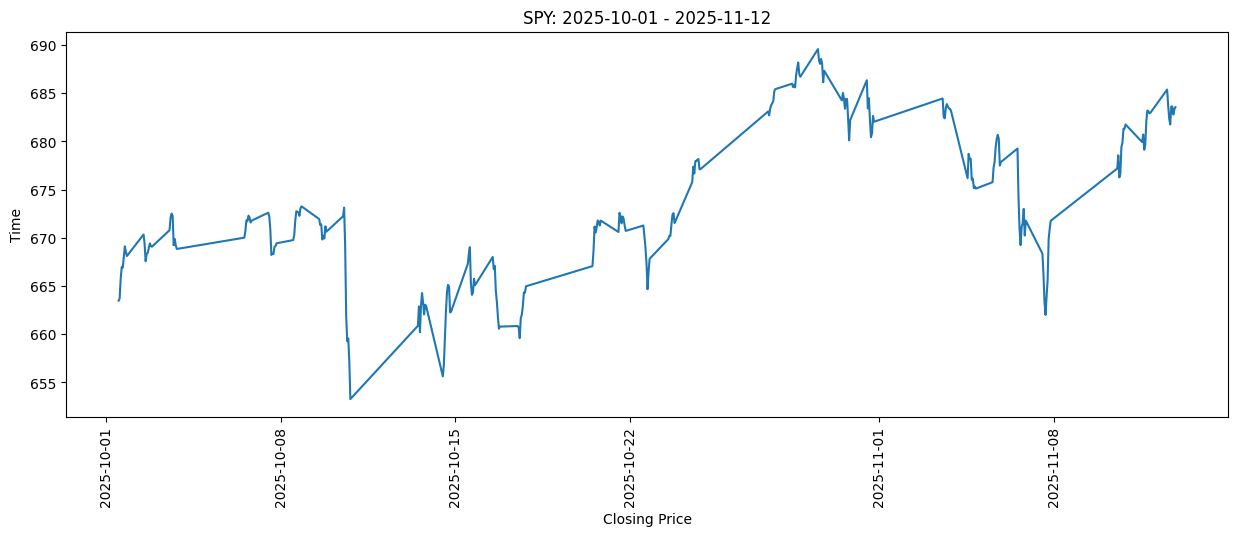

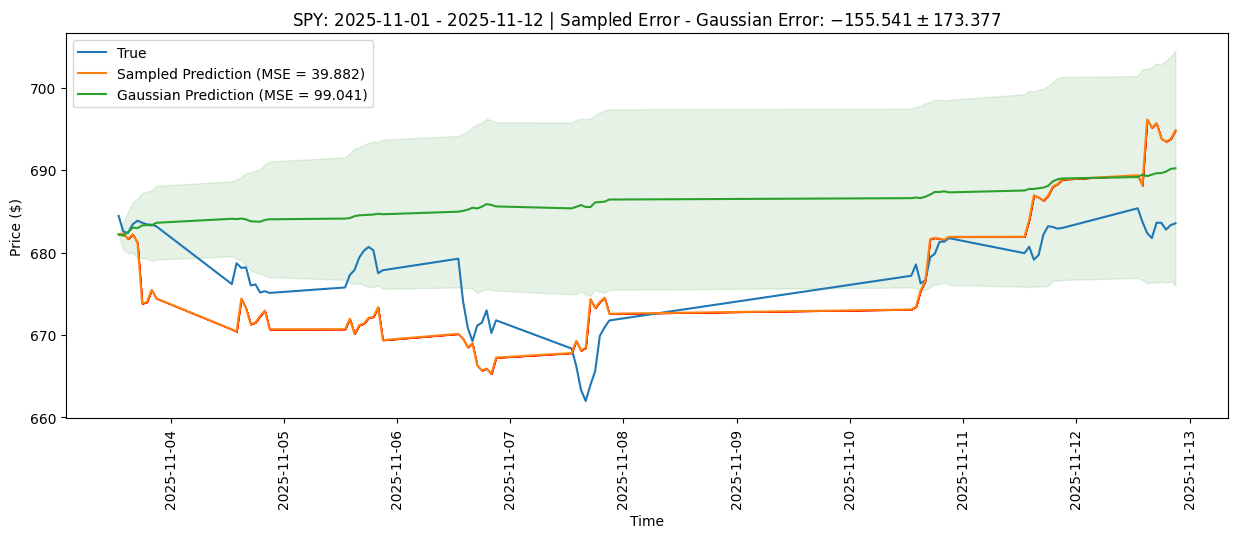

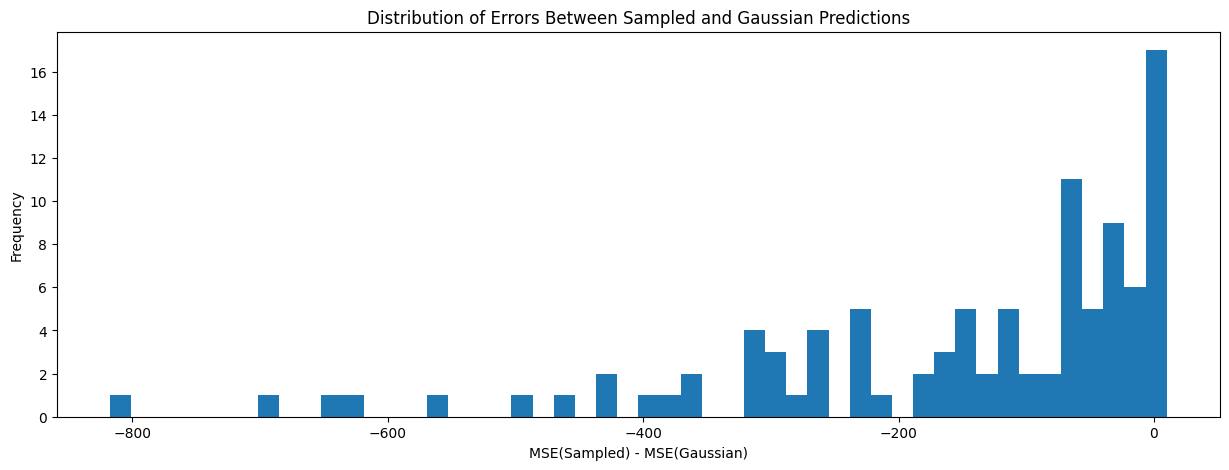

In [ ]:
get_prediction_error(symbol = 'SPY',
                     timeframe = '1H',
                     train_start_date = '2025-10-01',
                     train_end_date = '2025-10-31',
                     test_start_date = '2025-11-01',
                     test_end_date = '2025-11-12', 
                     headers = headers)

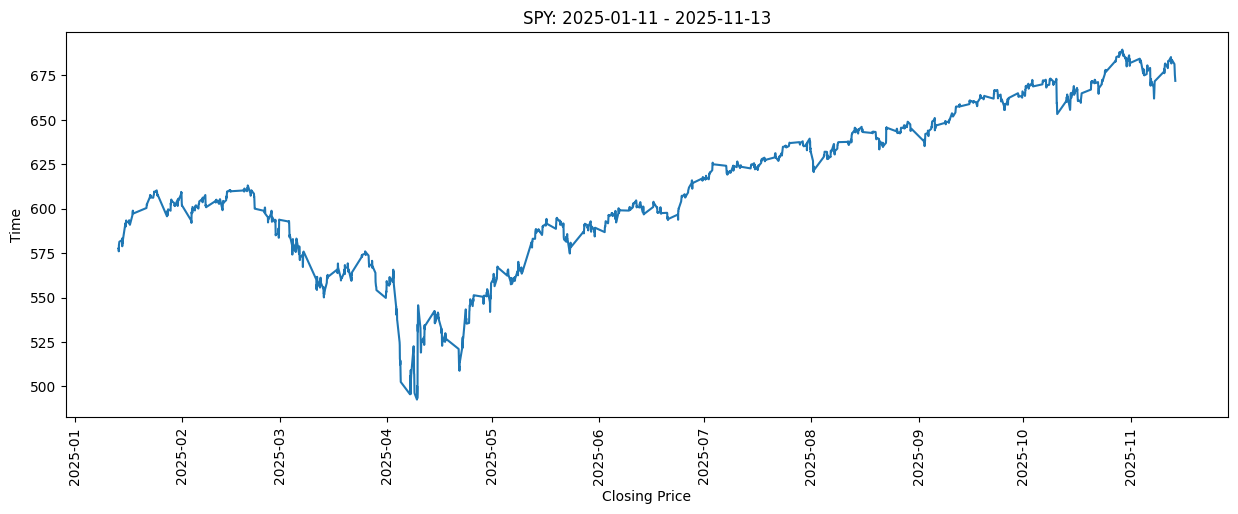

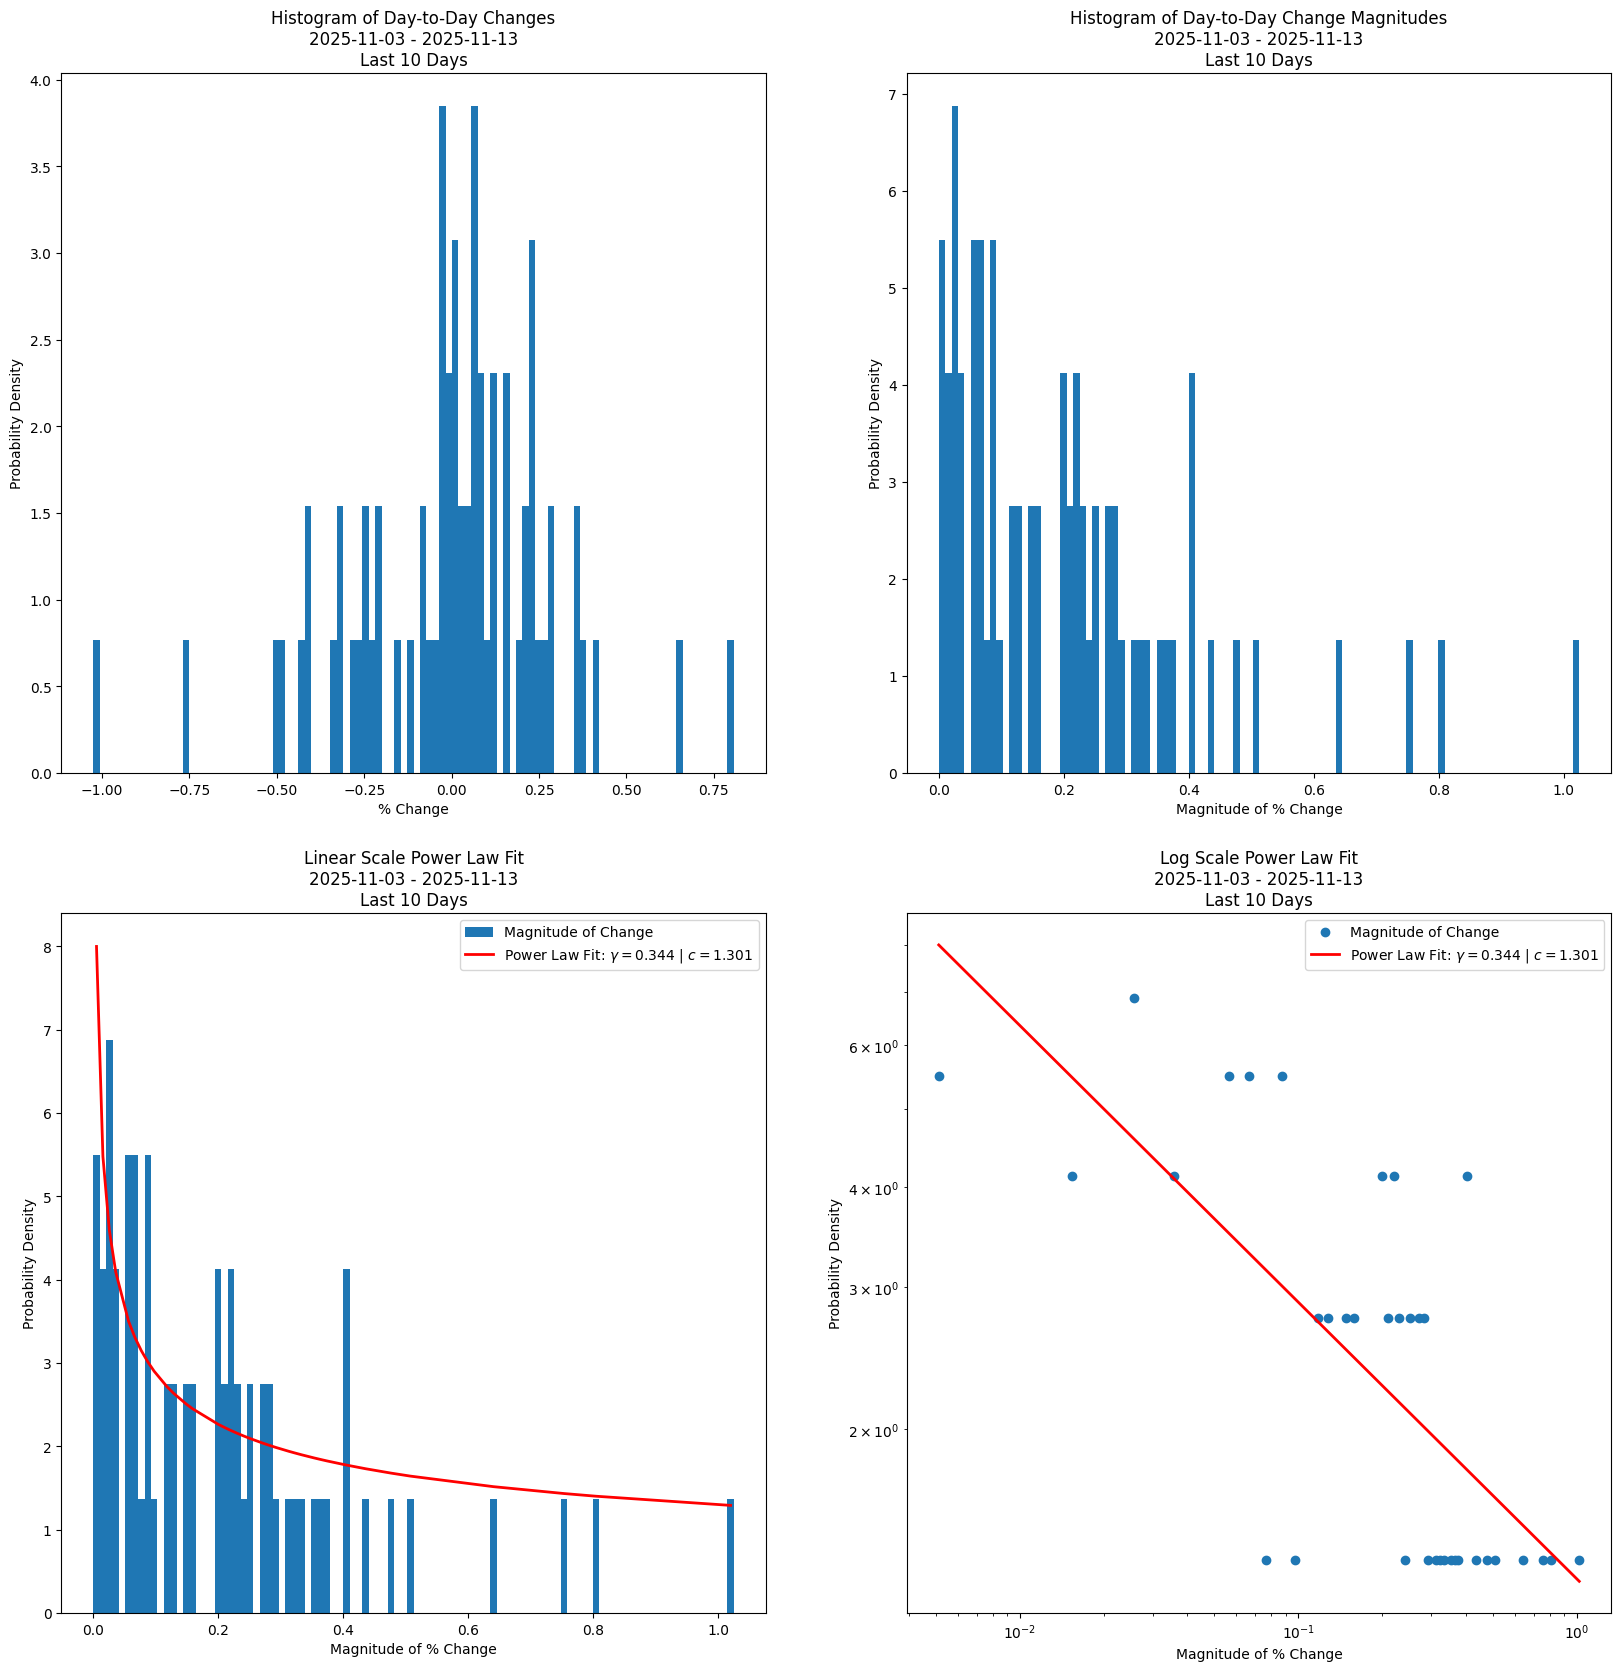

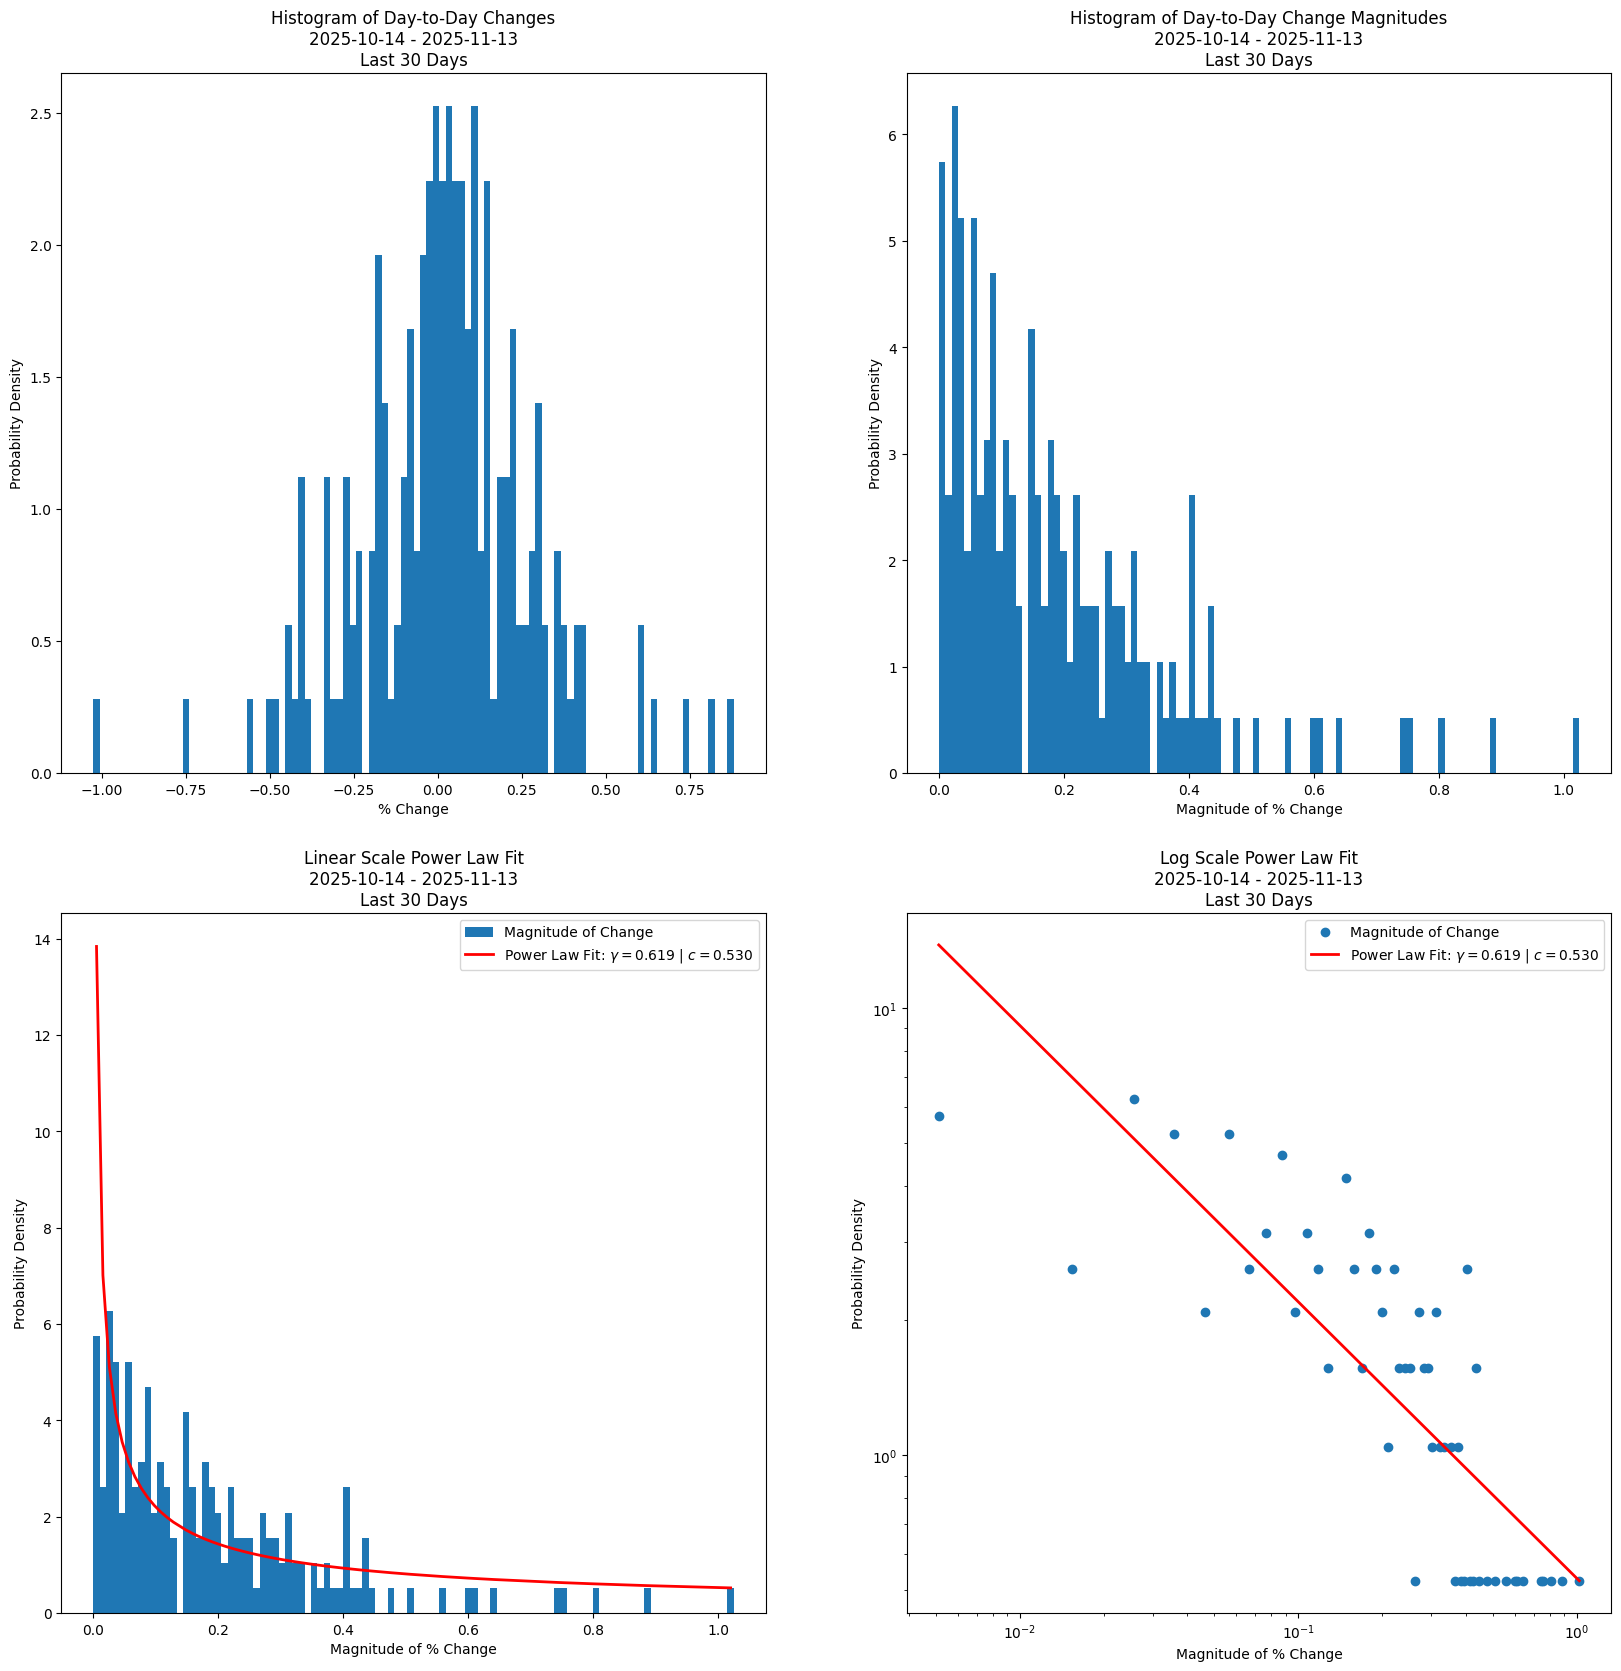

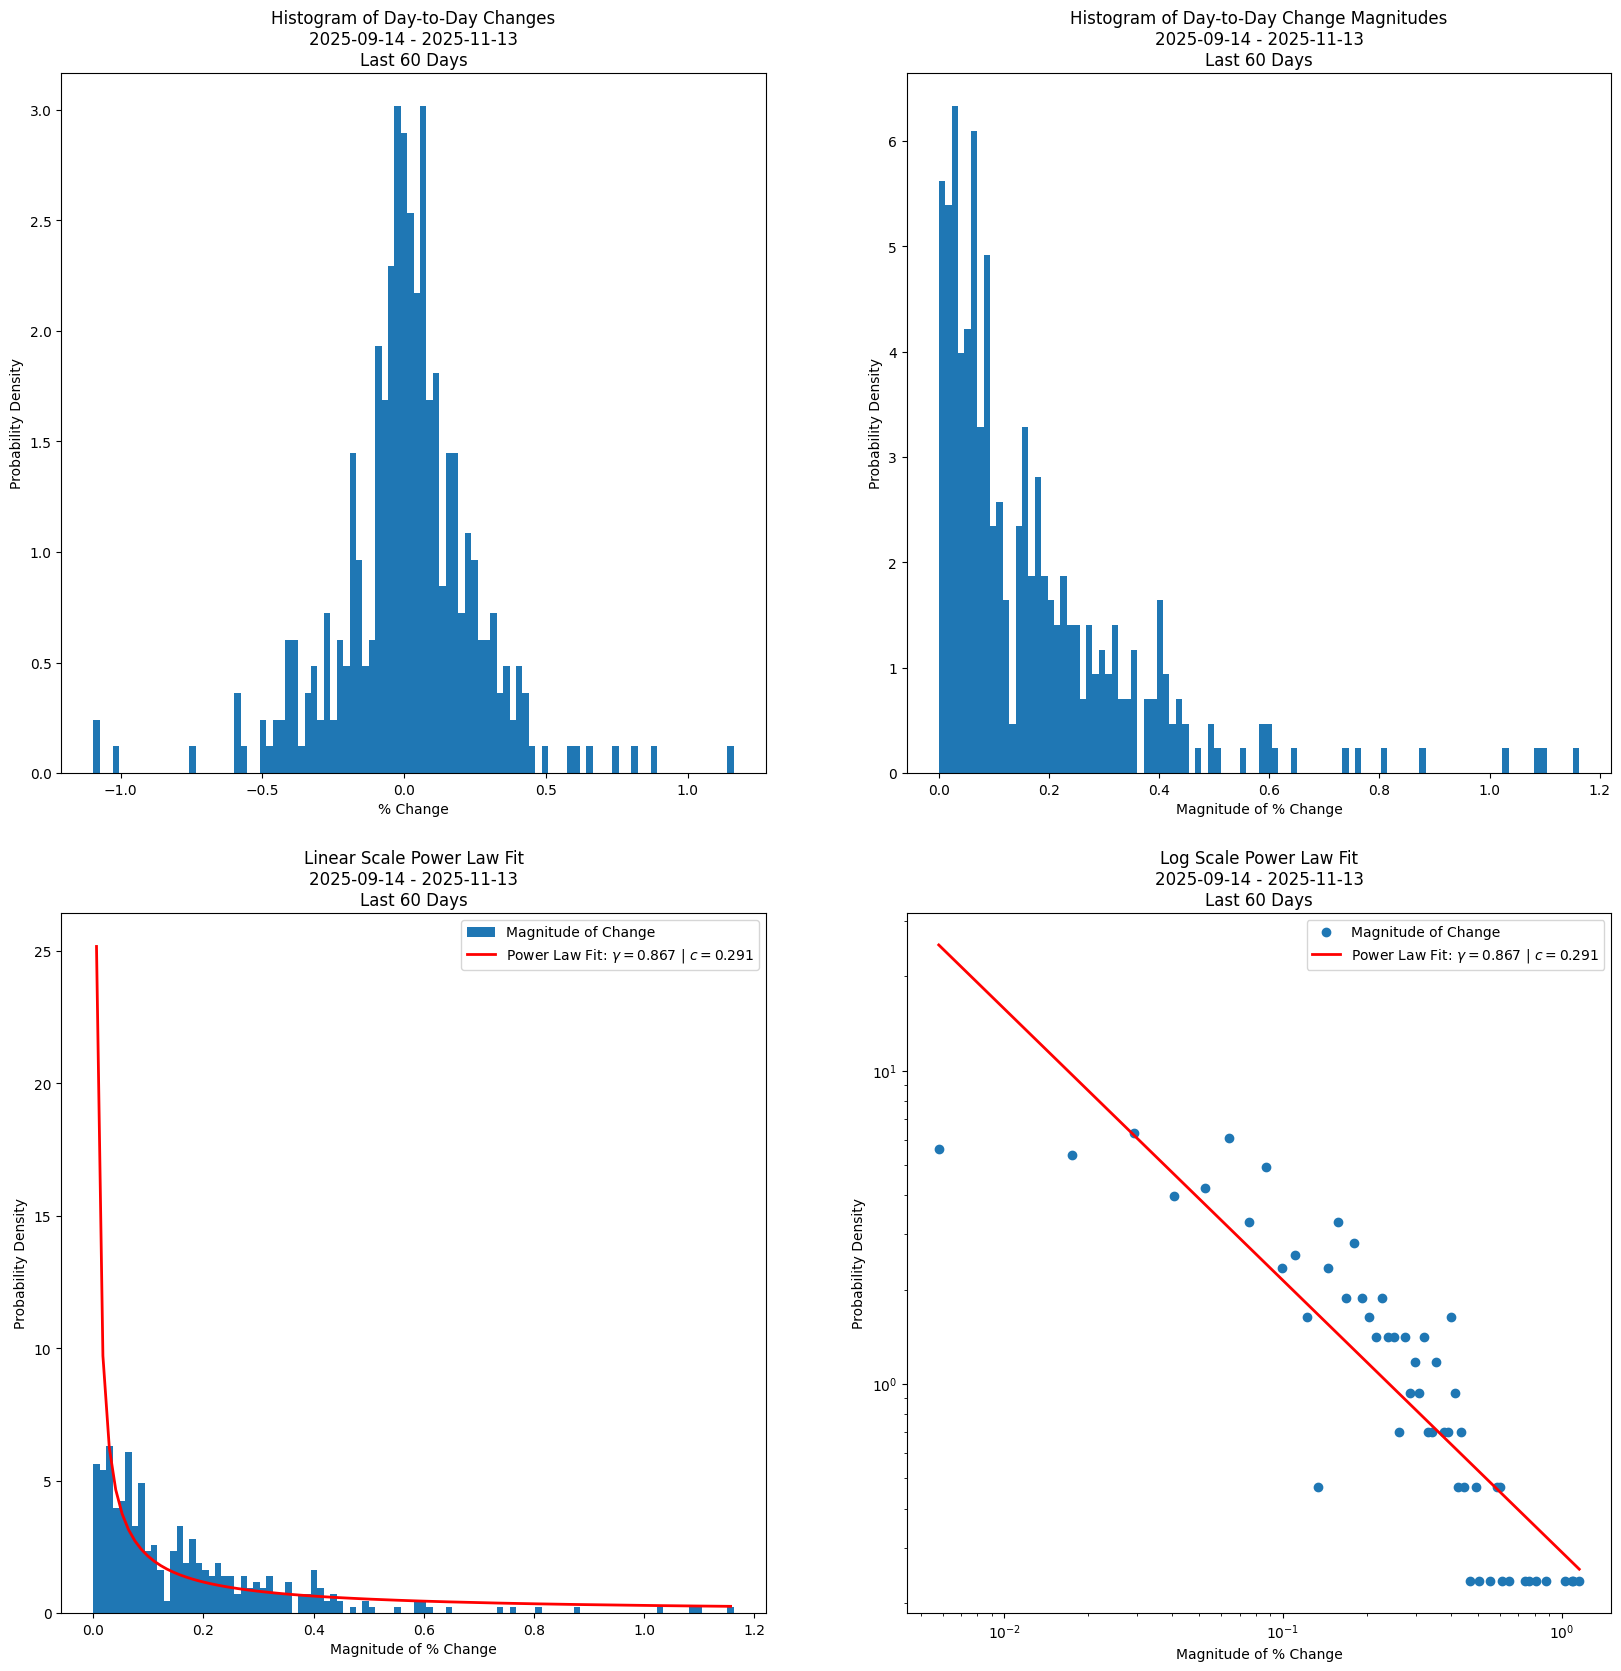

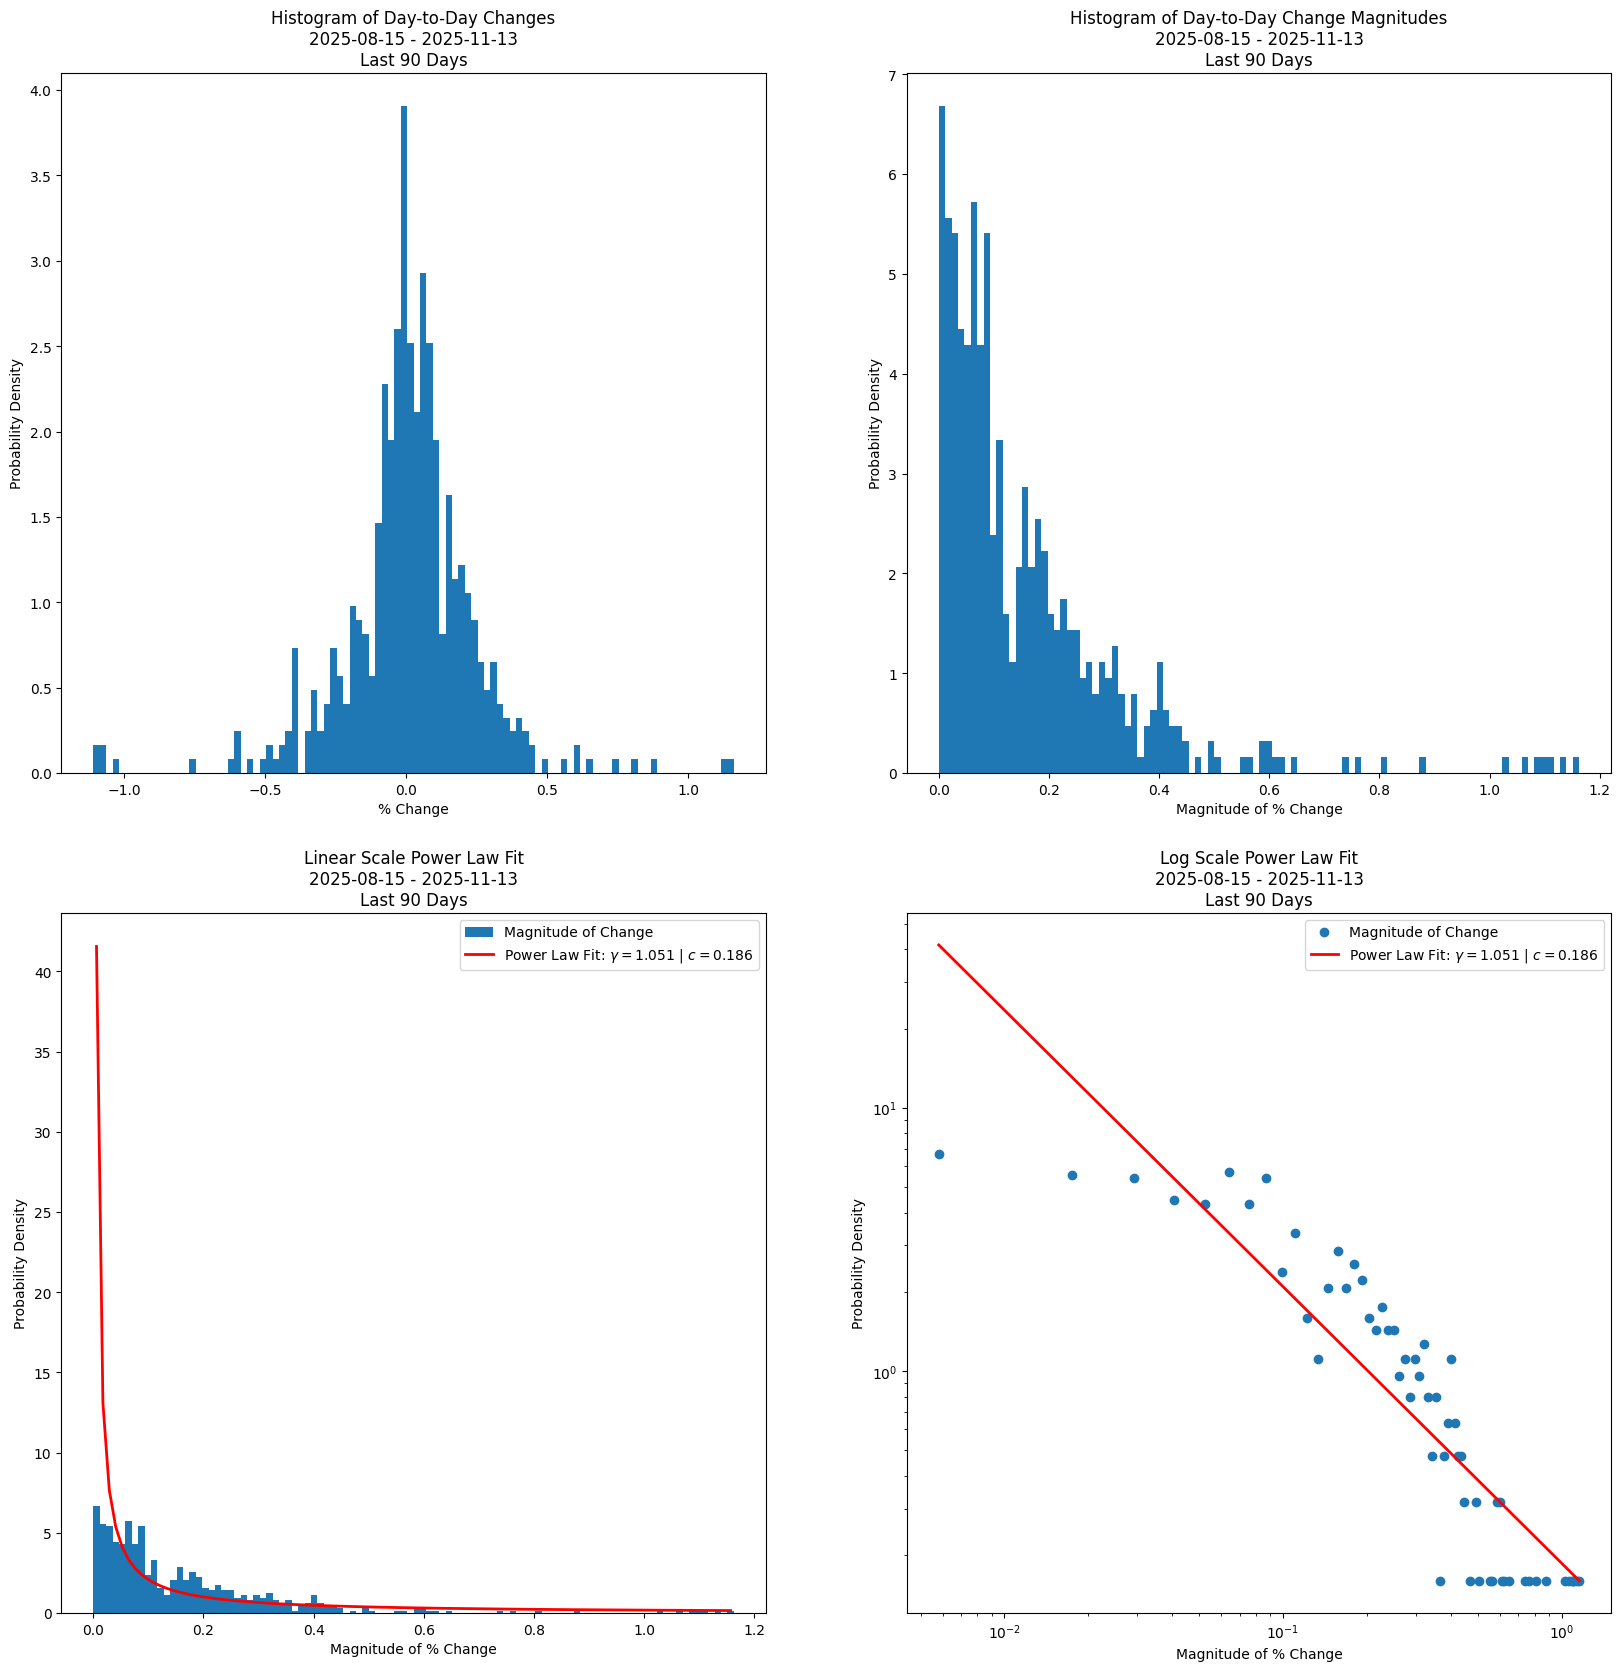

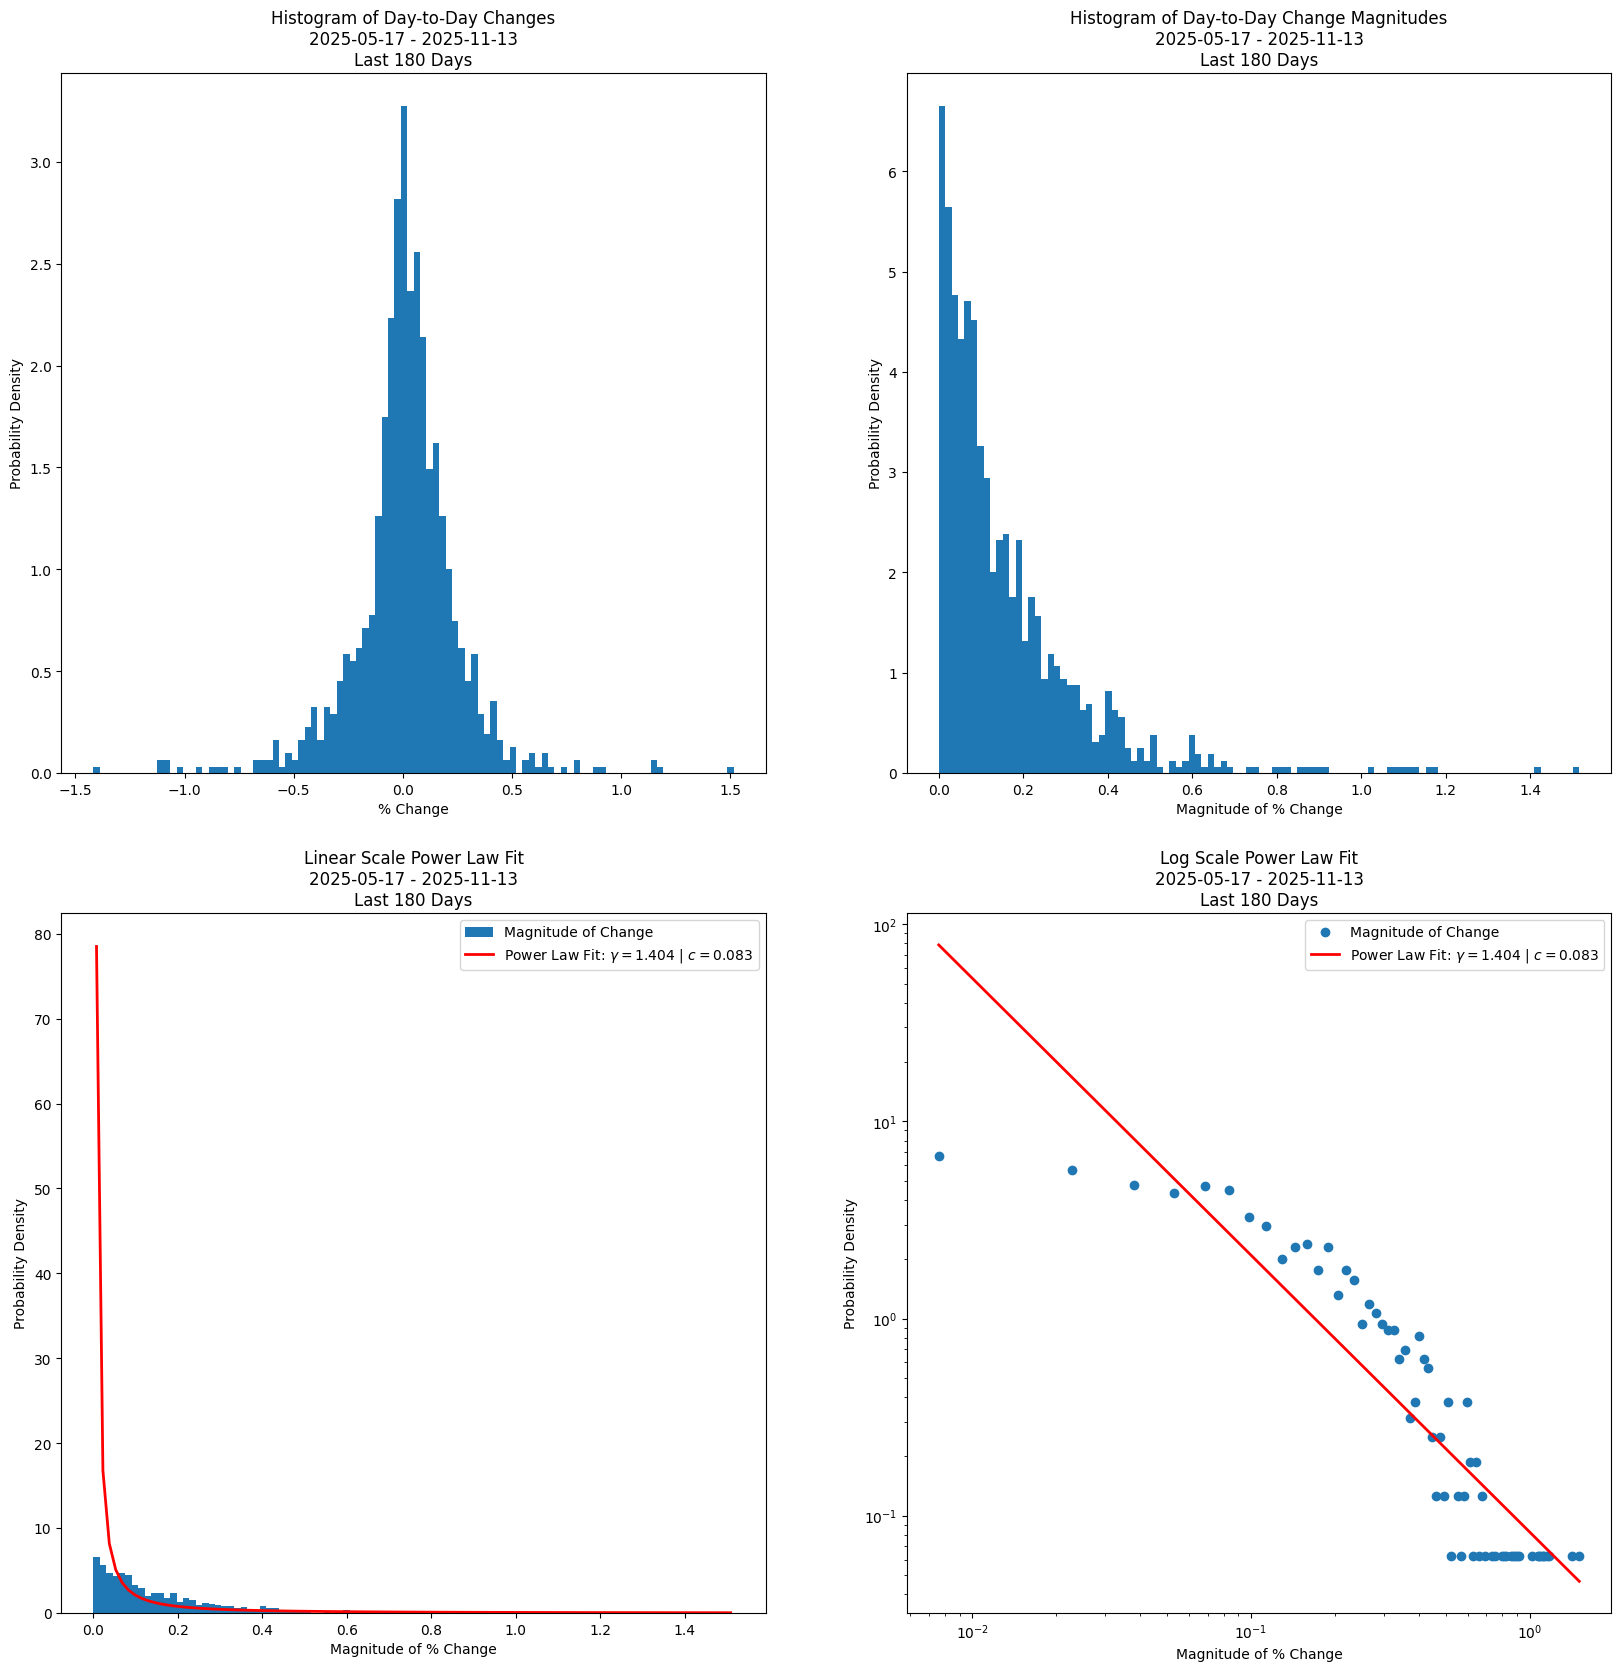

In [ ]:
get_historical_magnitude_plots(symbol = 'SPY',
                                timeframe = '1H',
                                historical_start_date = '2025-01-11',
                                historical_end_date = 'now',
                                day_offsets = [10, 30, 60, 90, 180], 
                                headers = headers)

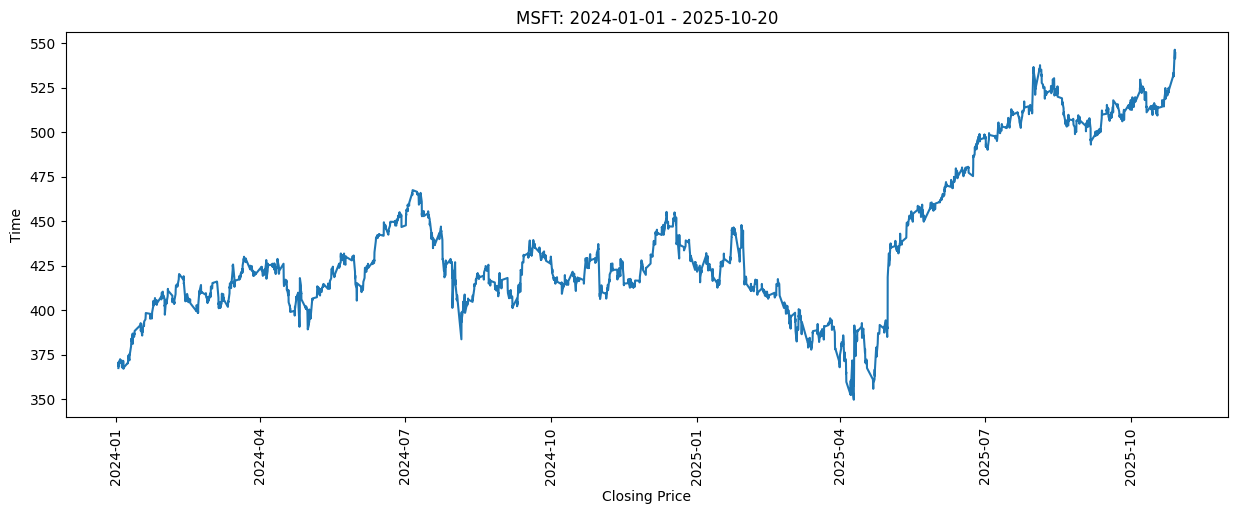

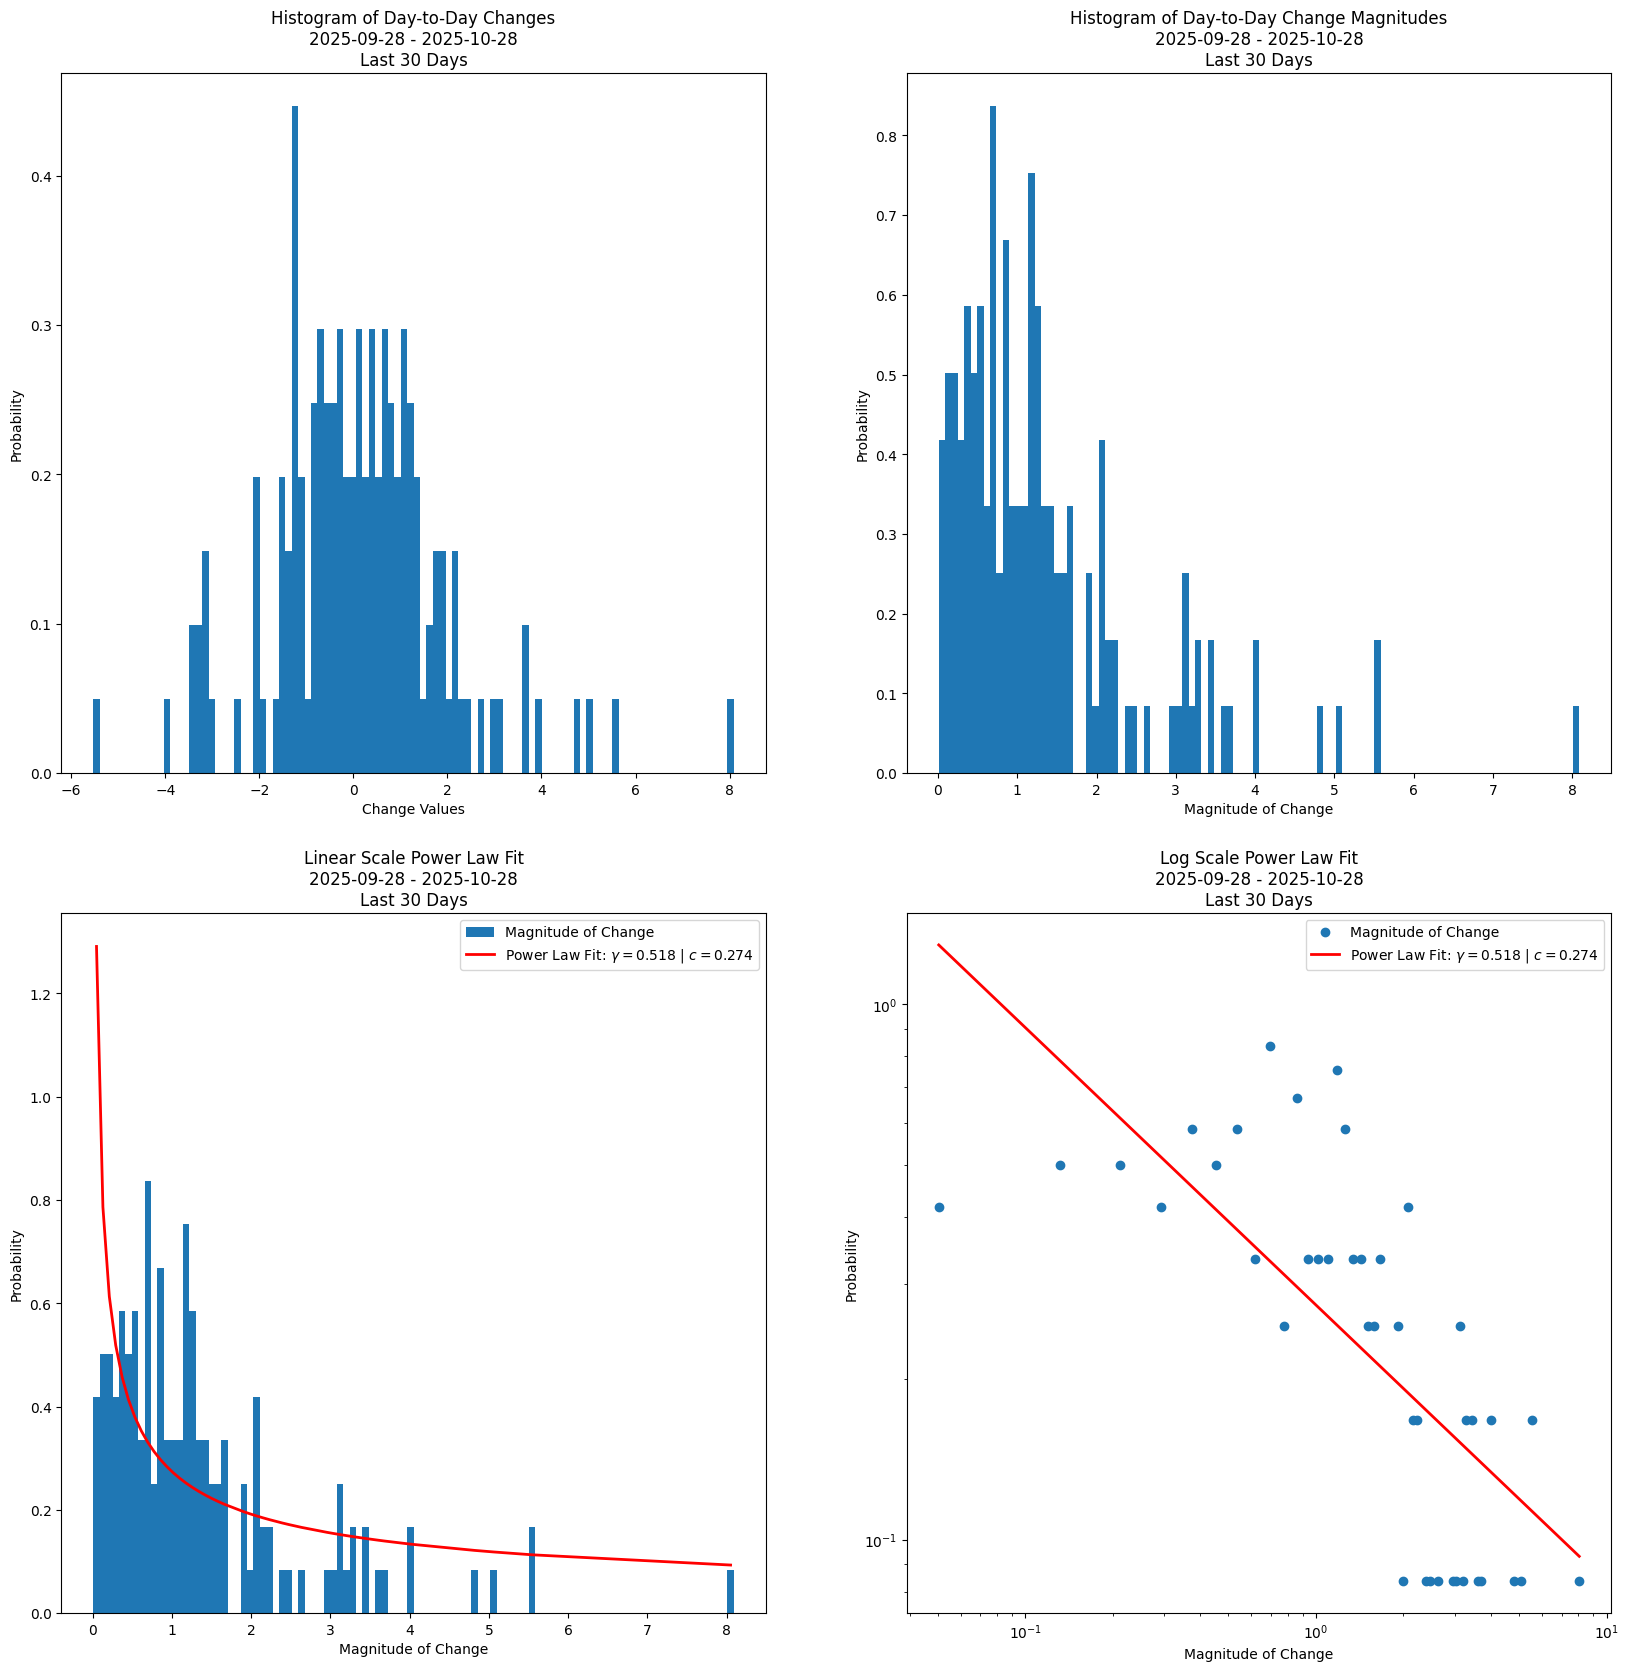

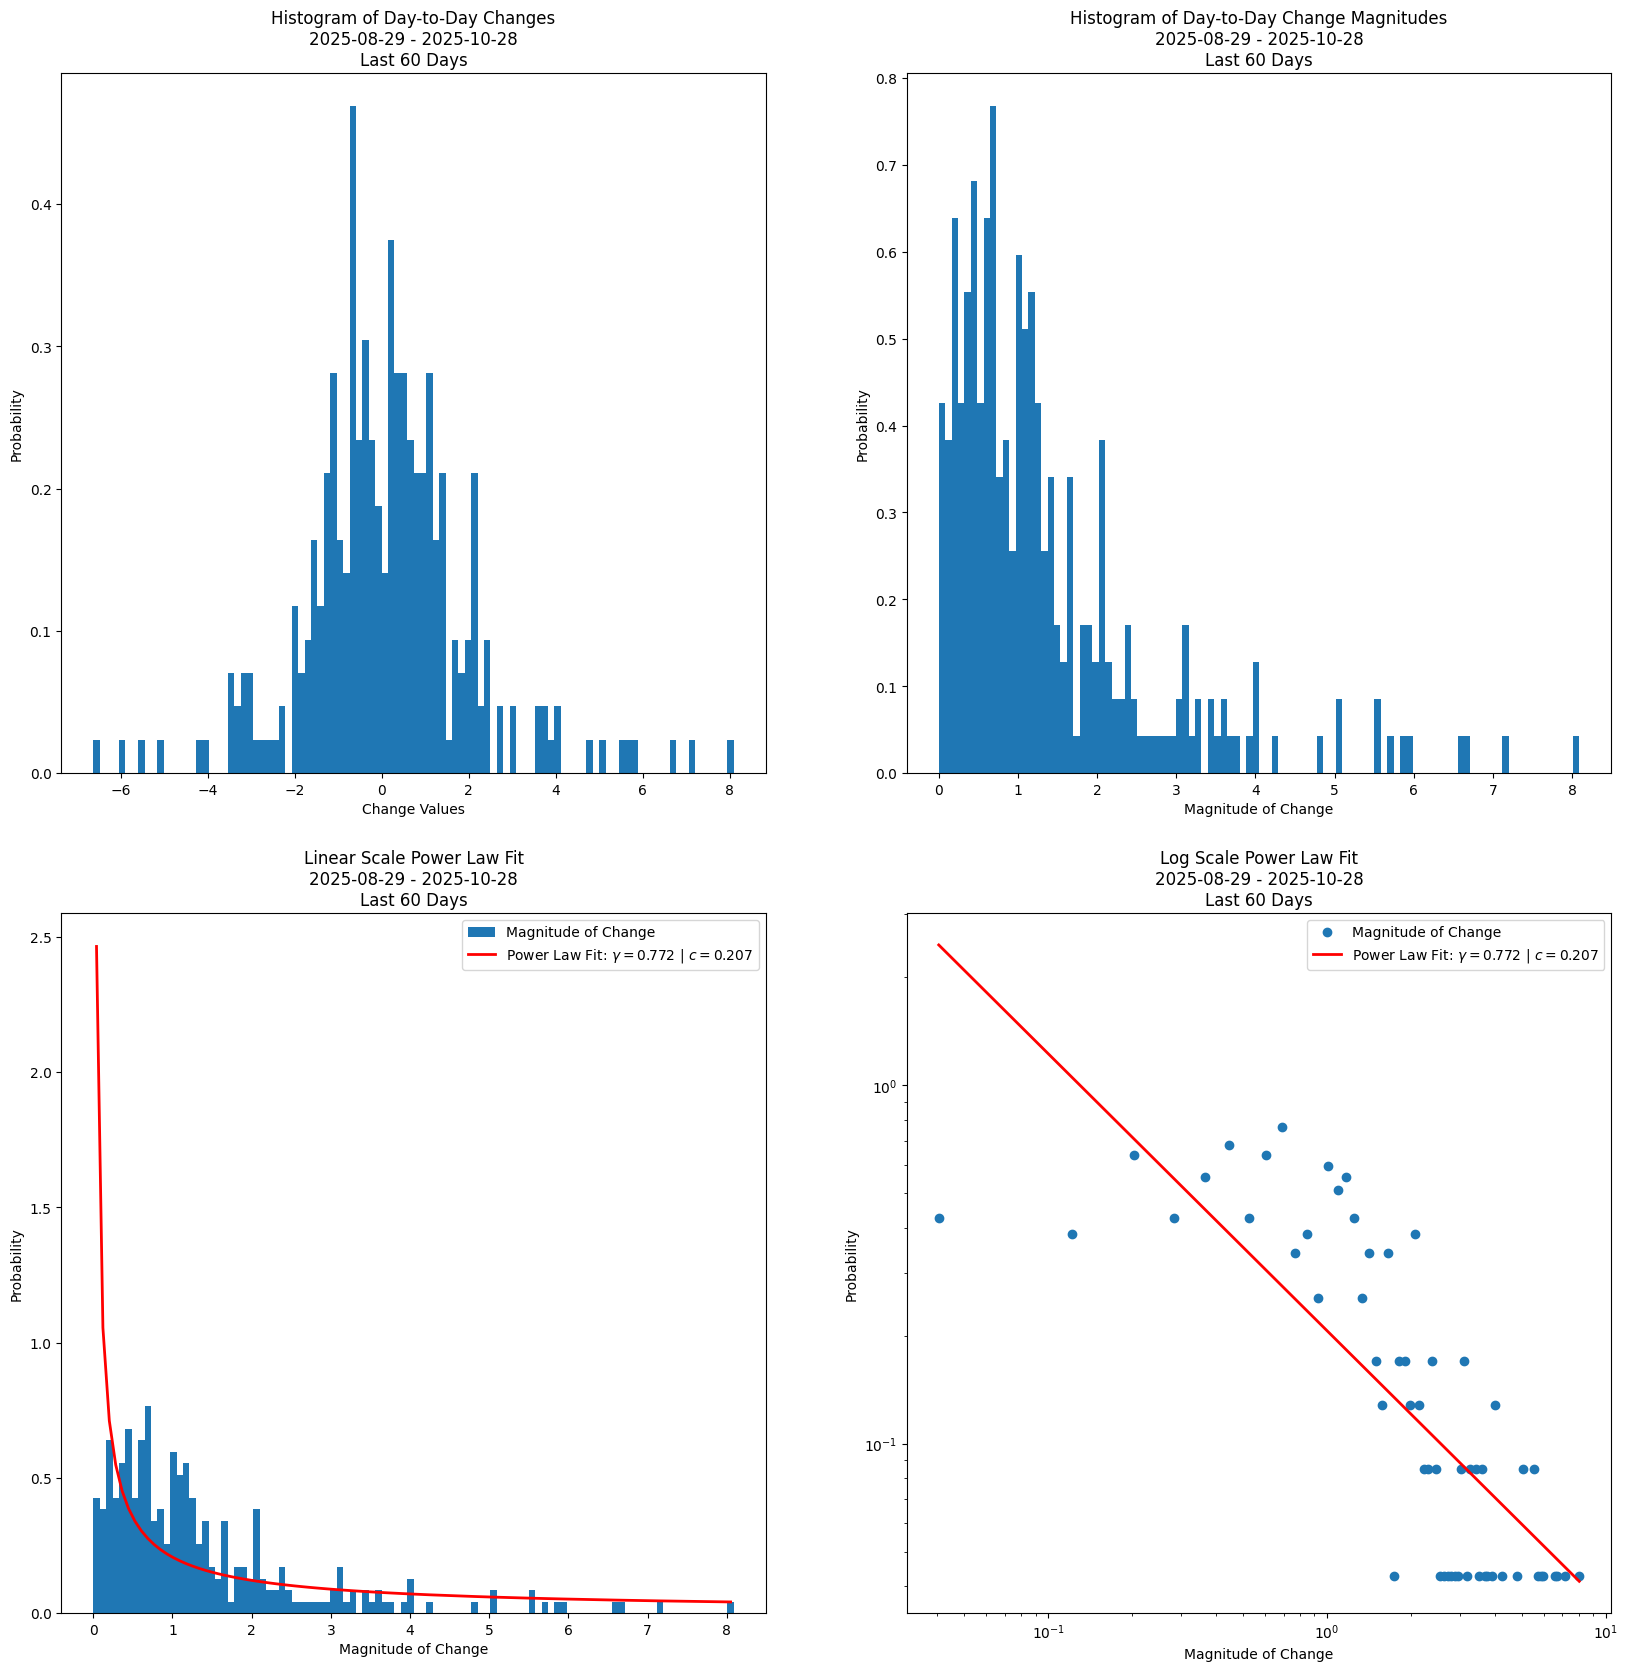

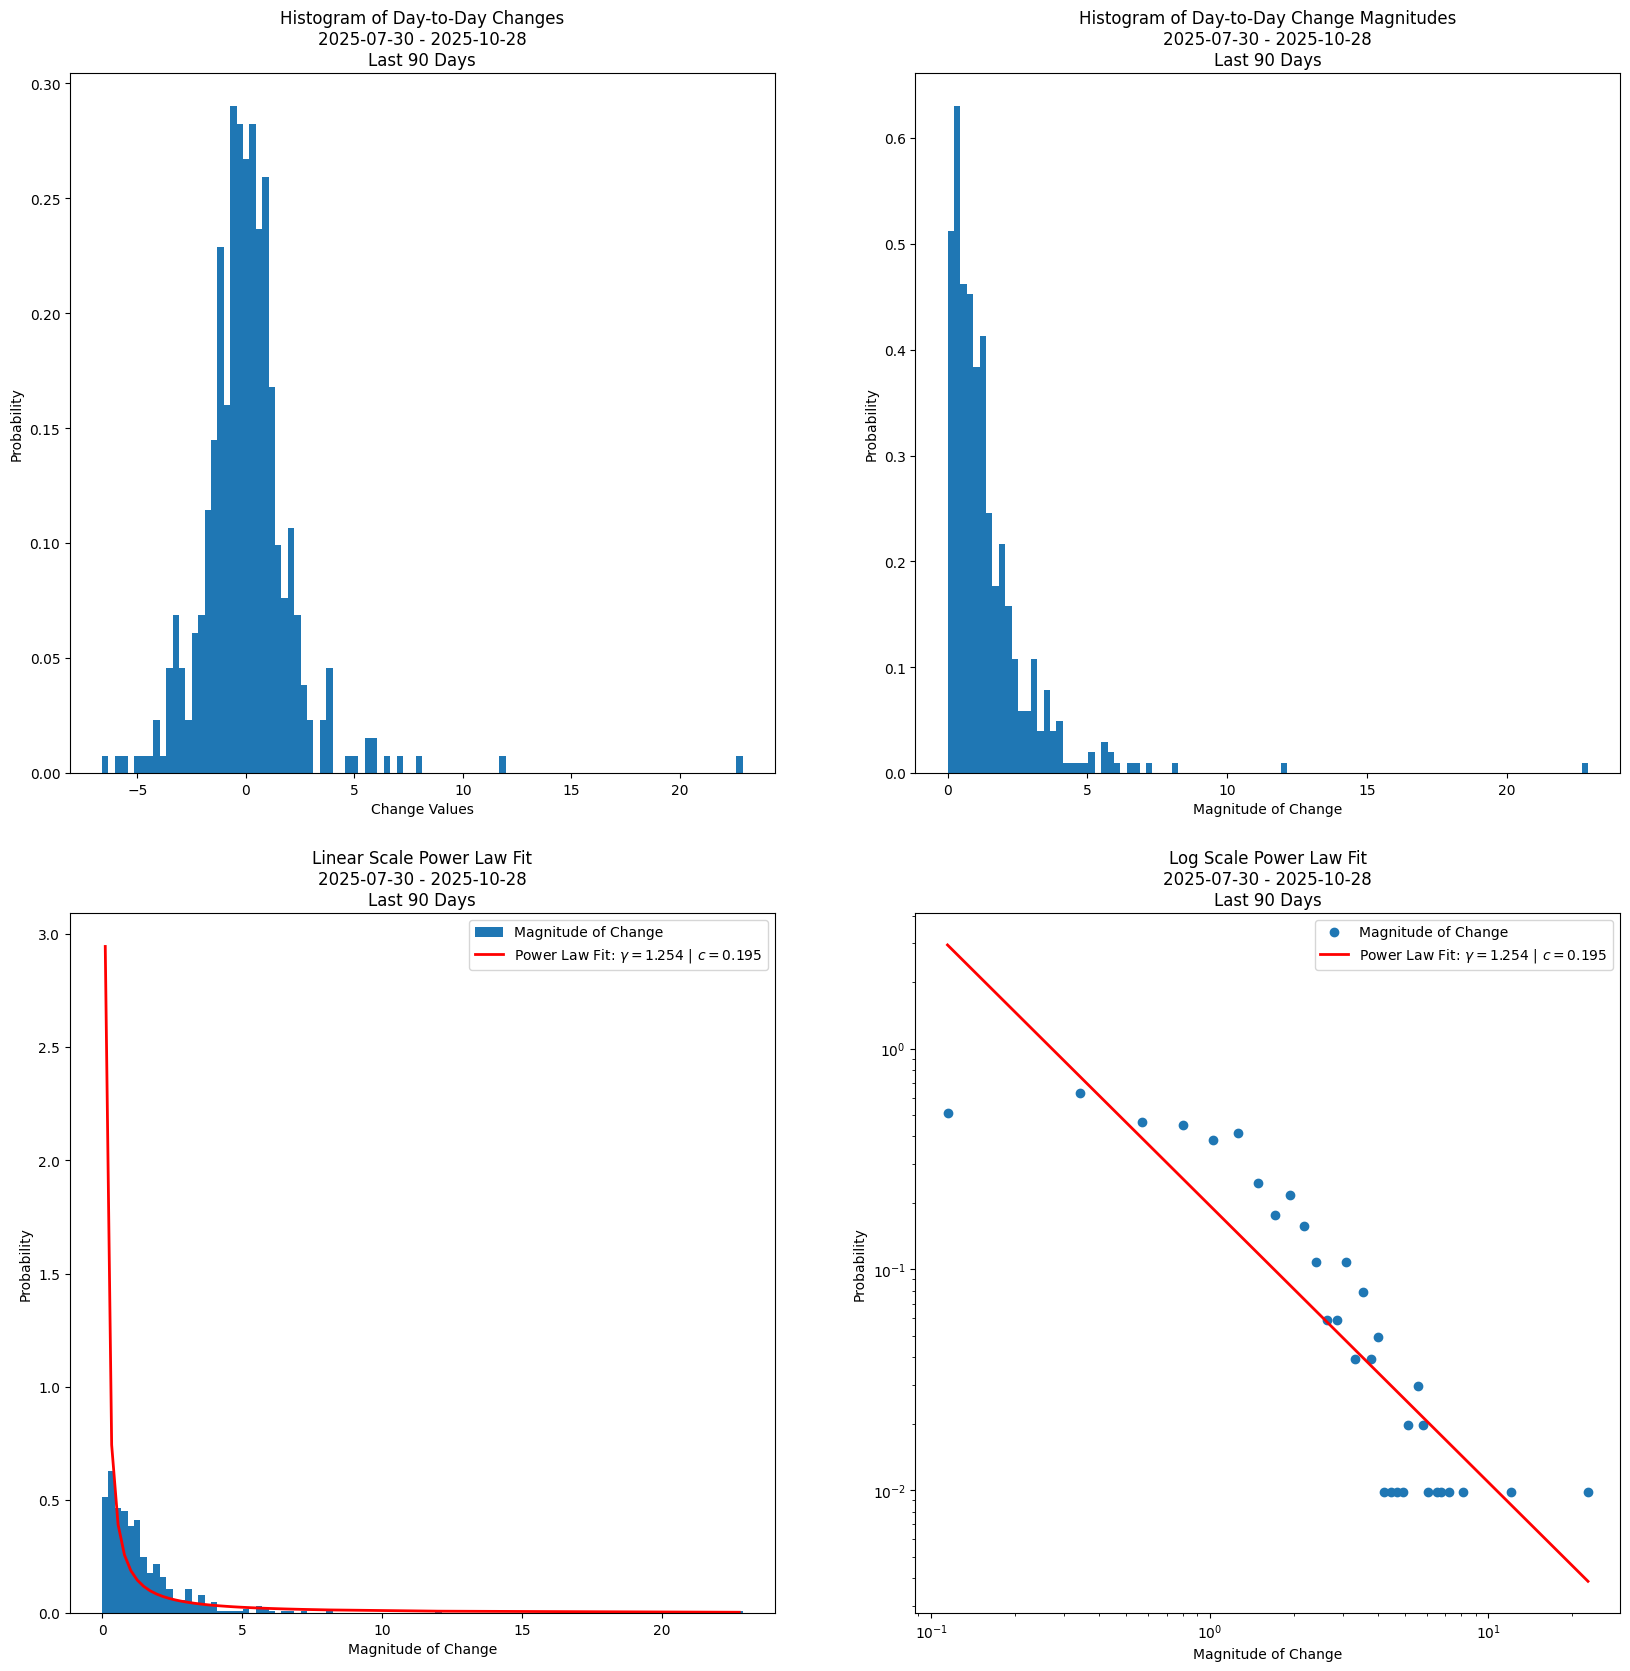

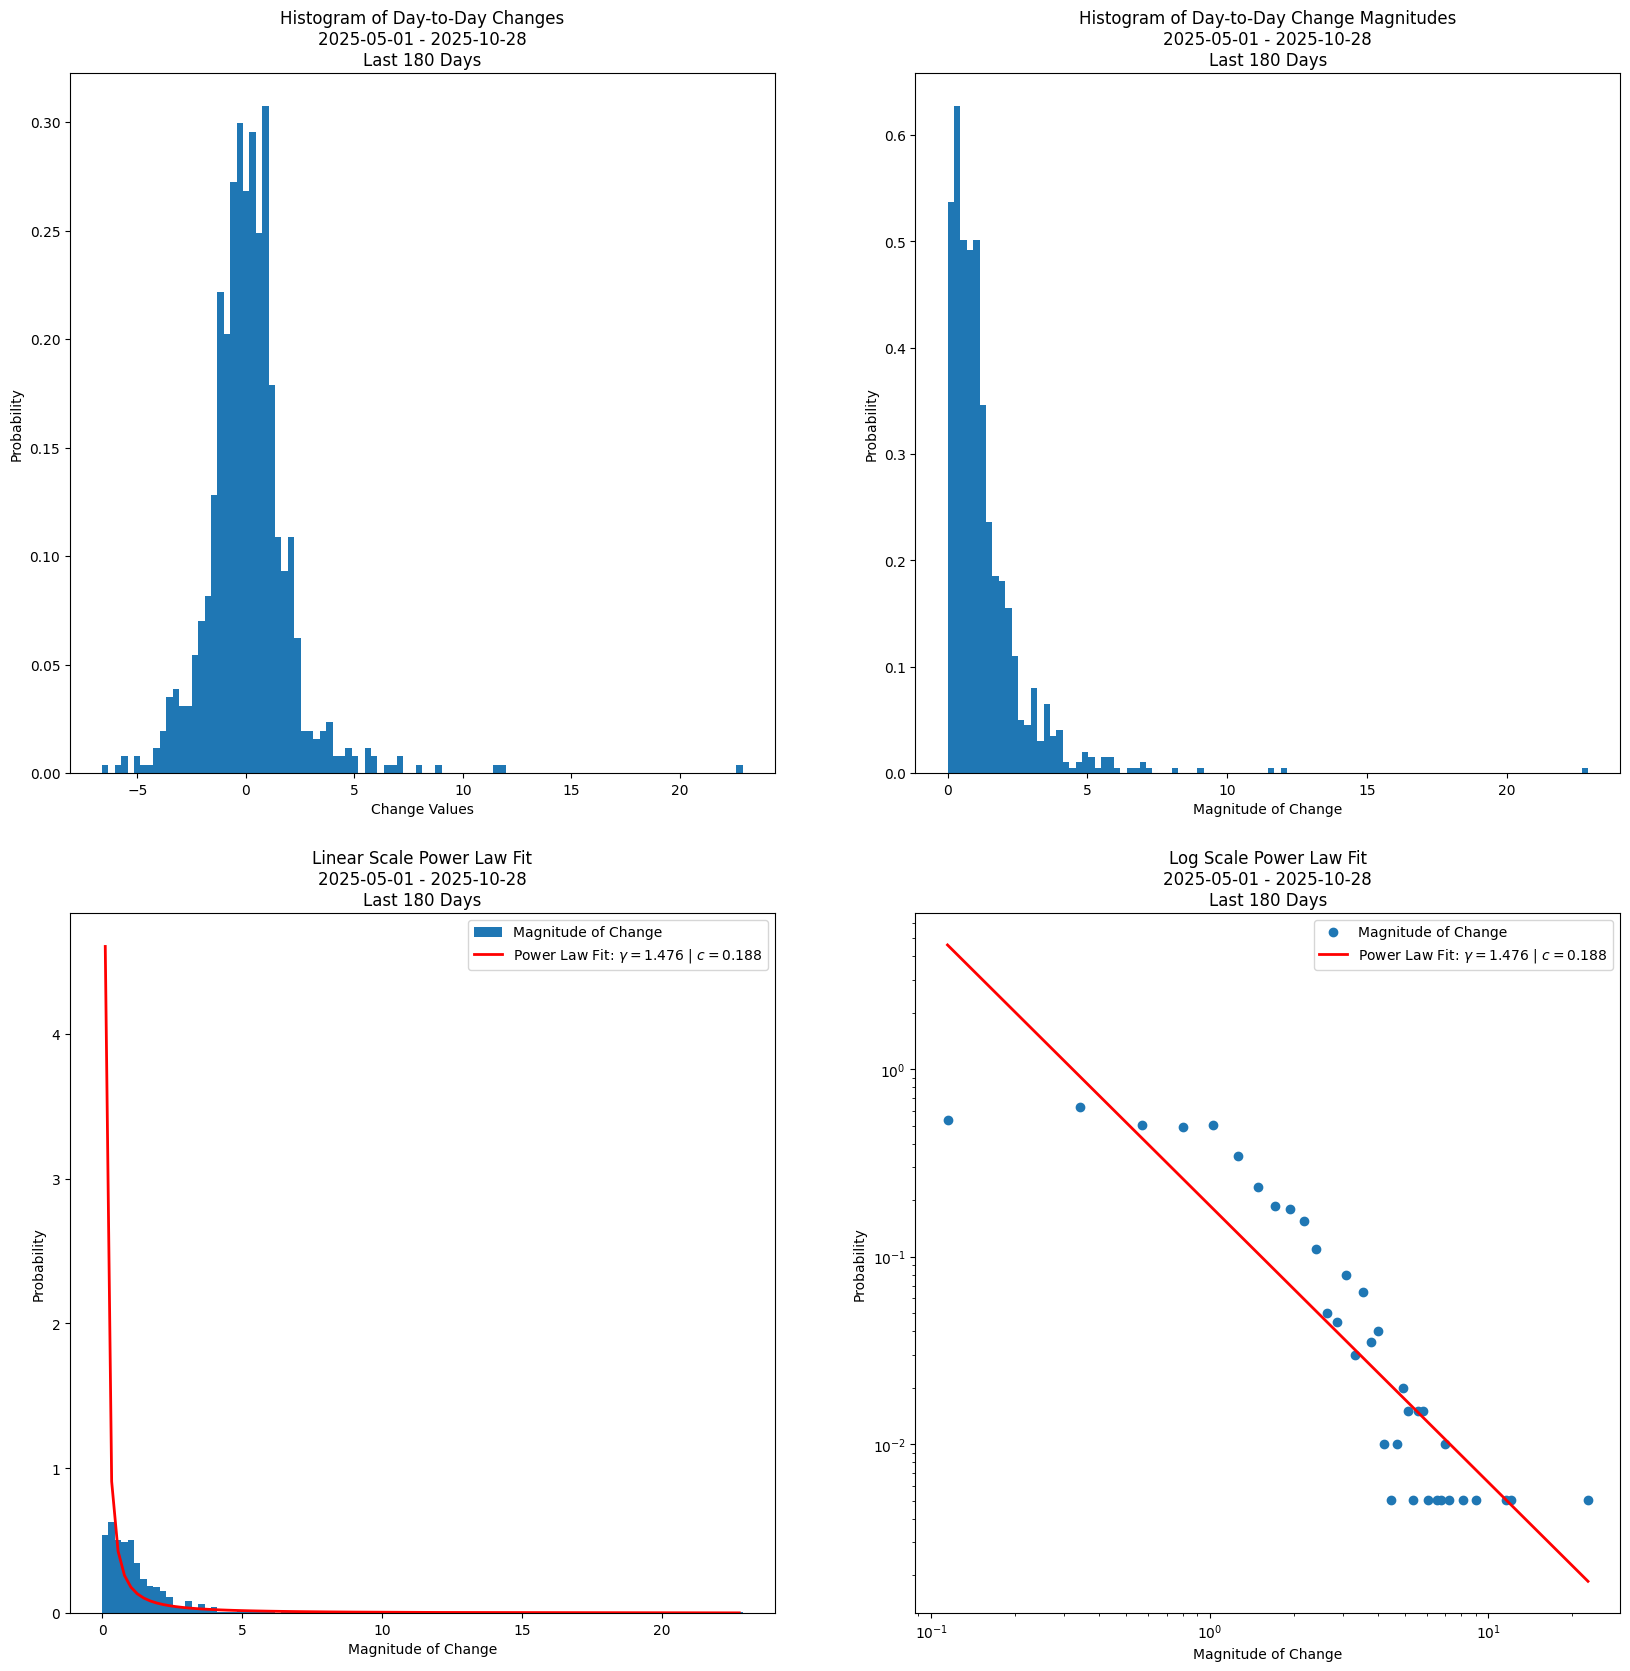

In [ ]:
get_historical_magnitude_plots(symbol = 'MSFT',
                                timeframe = '1H',
                                historical_start_date = '2024-01-01',
                                historical_end_date = 'now',
                                day_offsets = [30, 60, 90, 180])

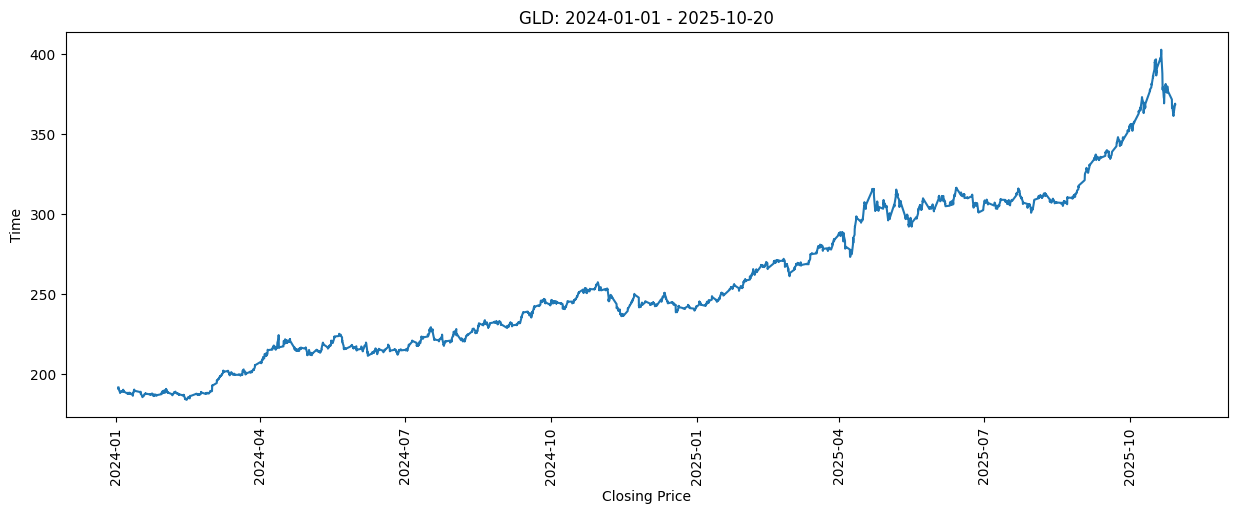

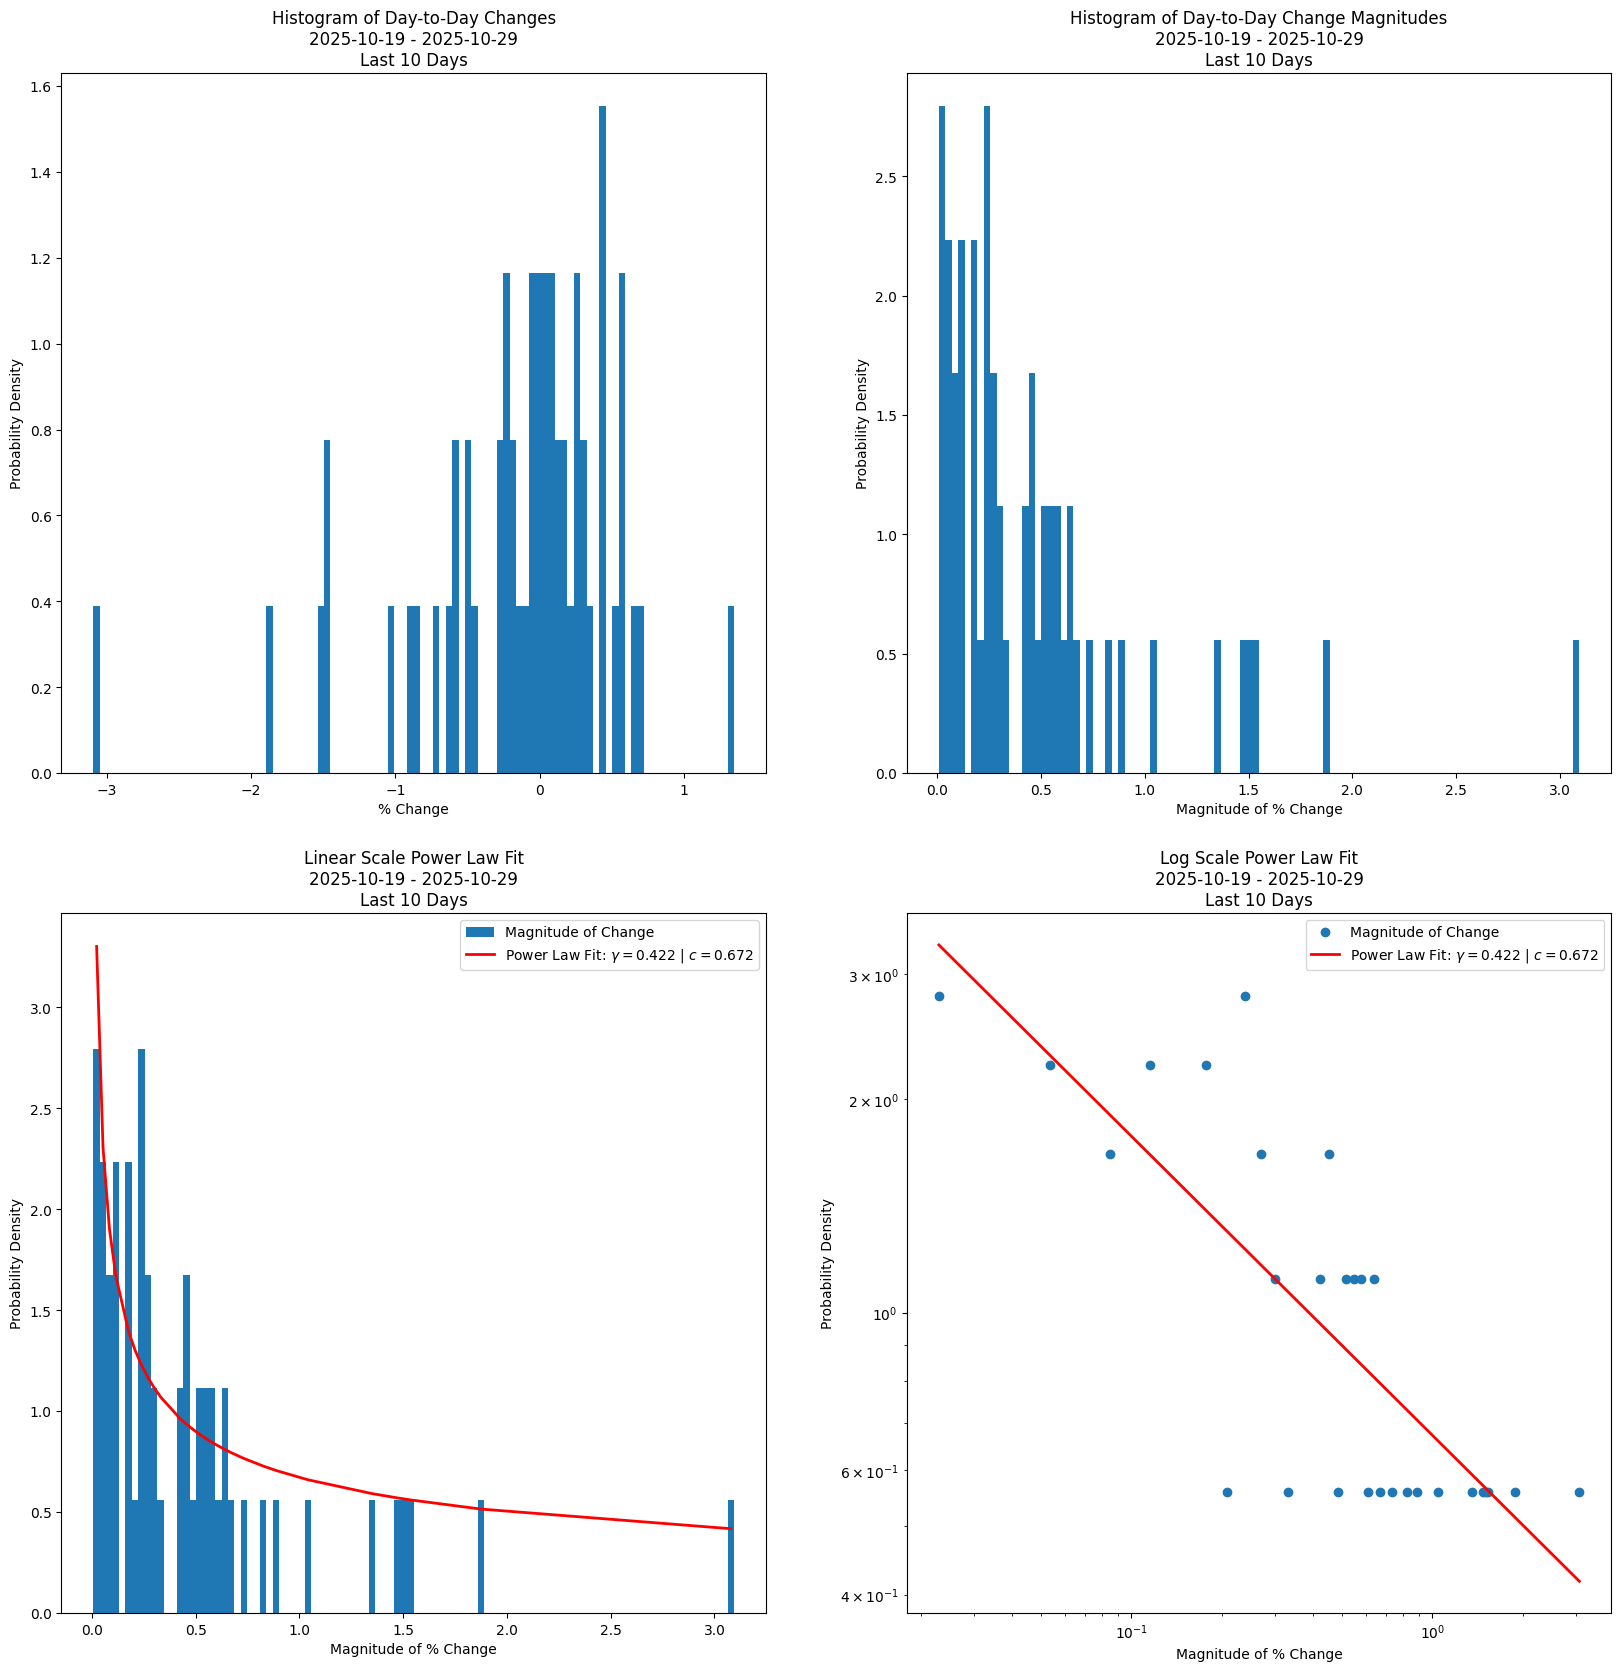

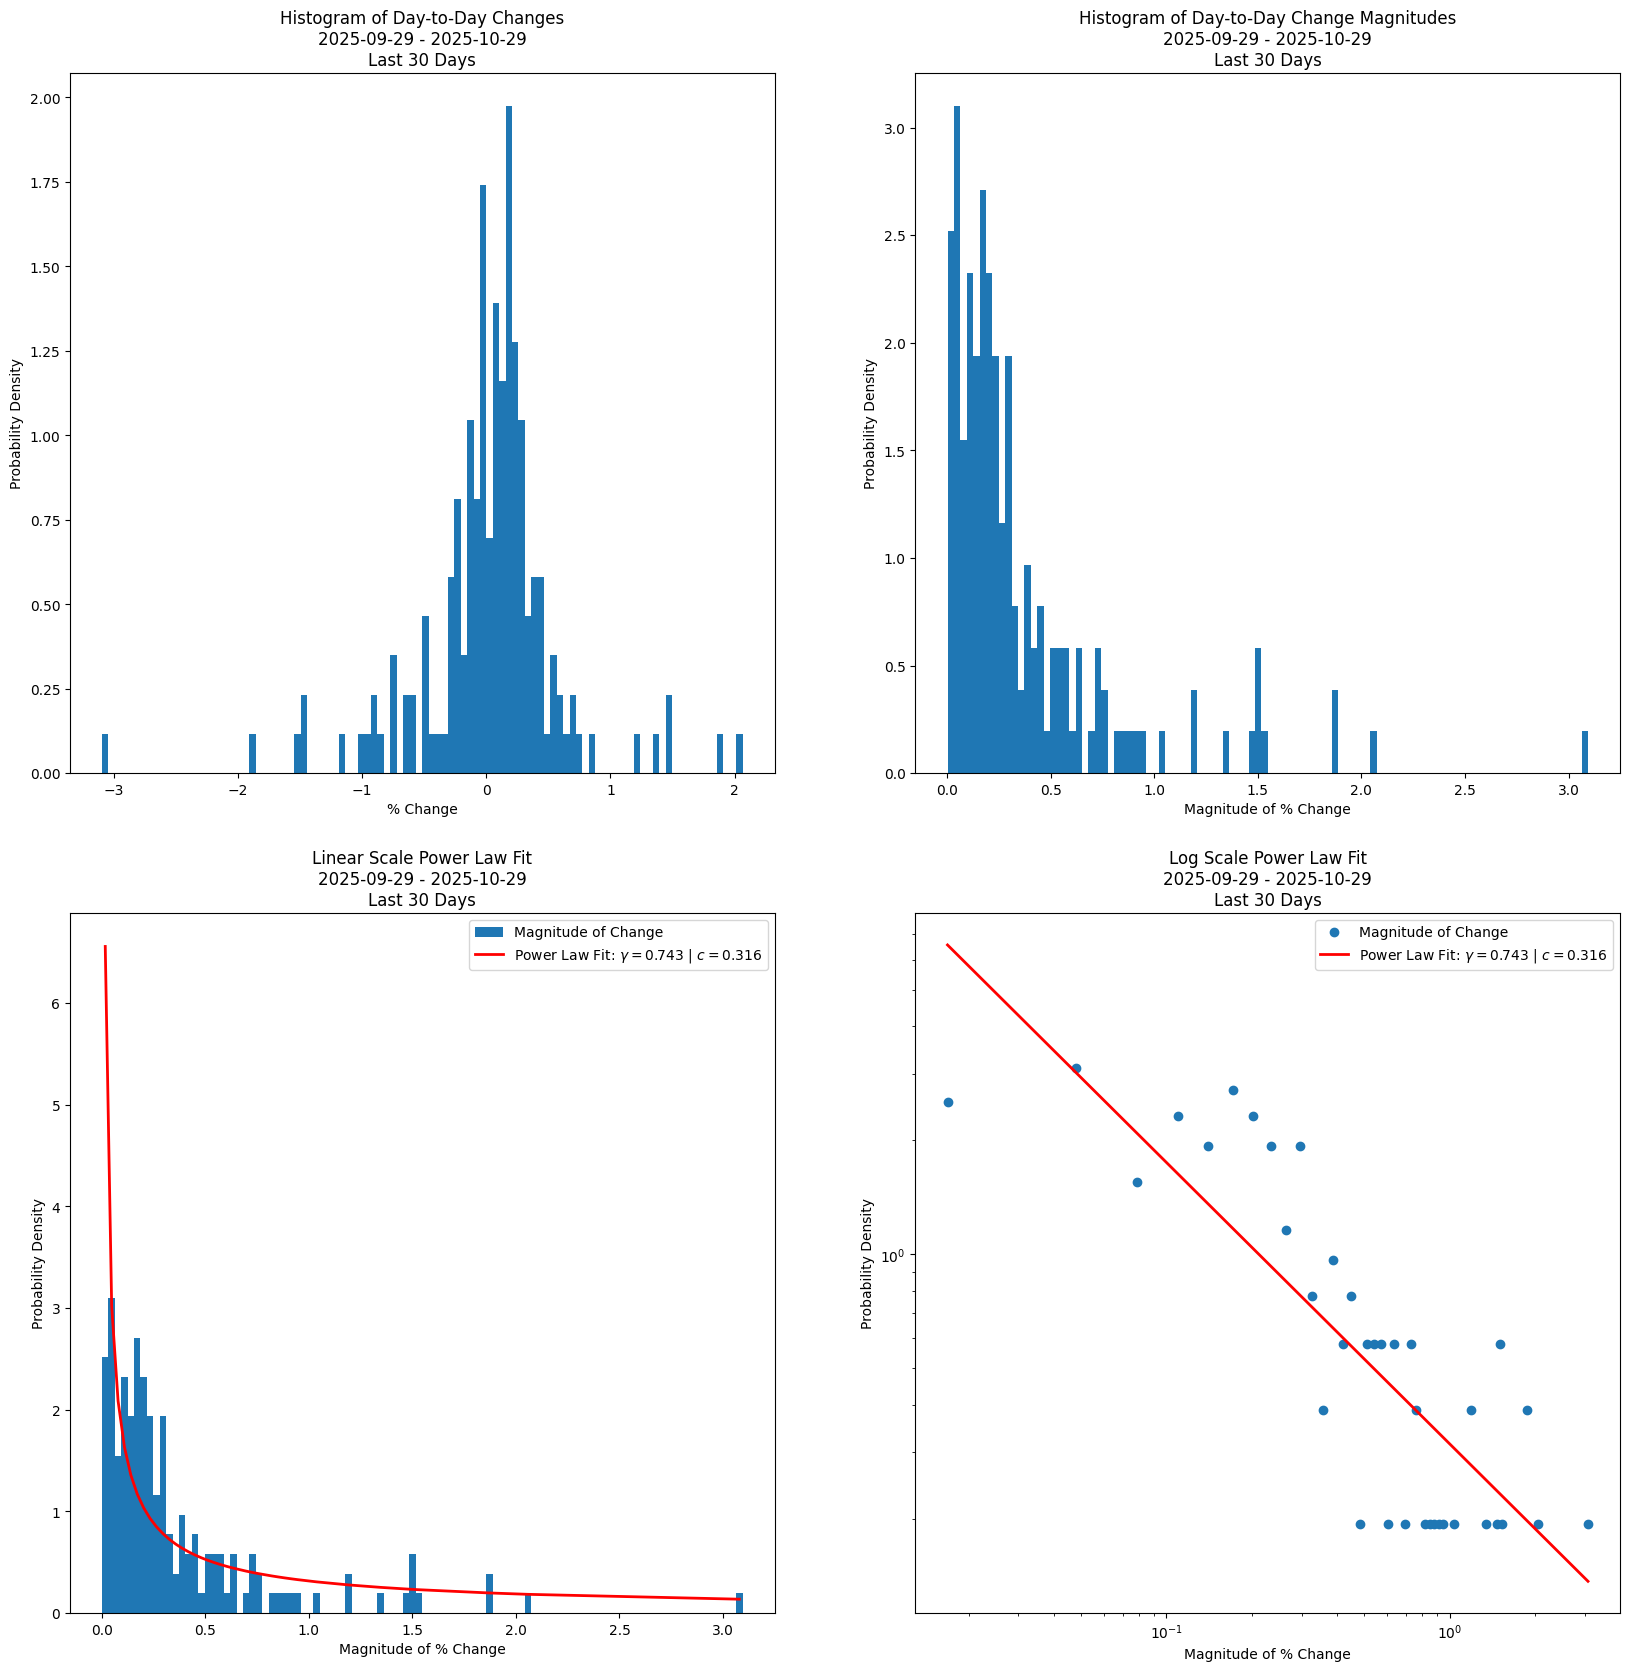

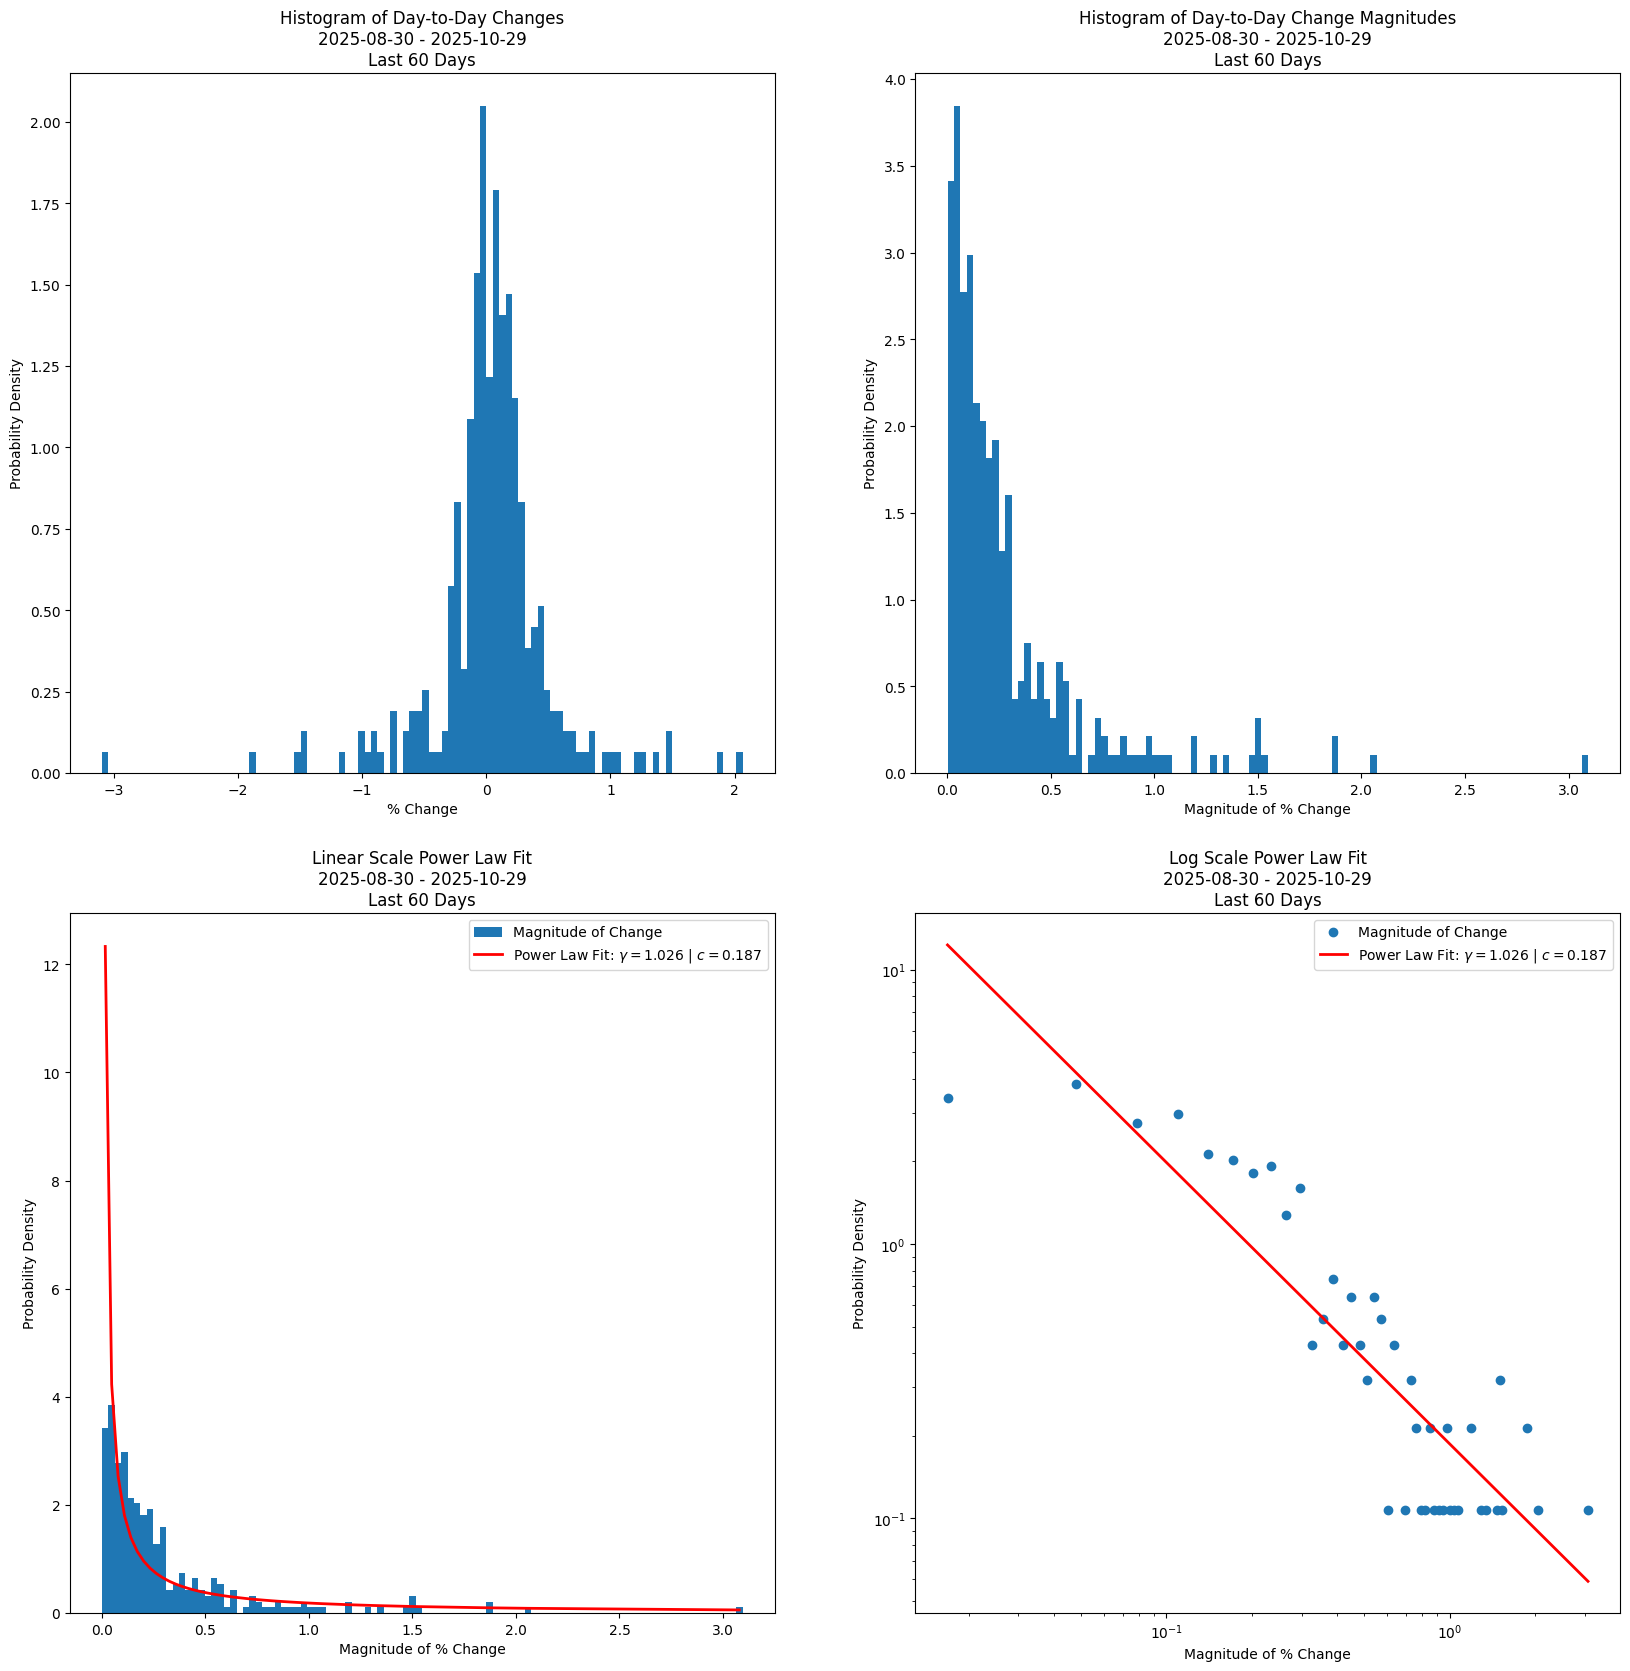

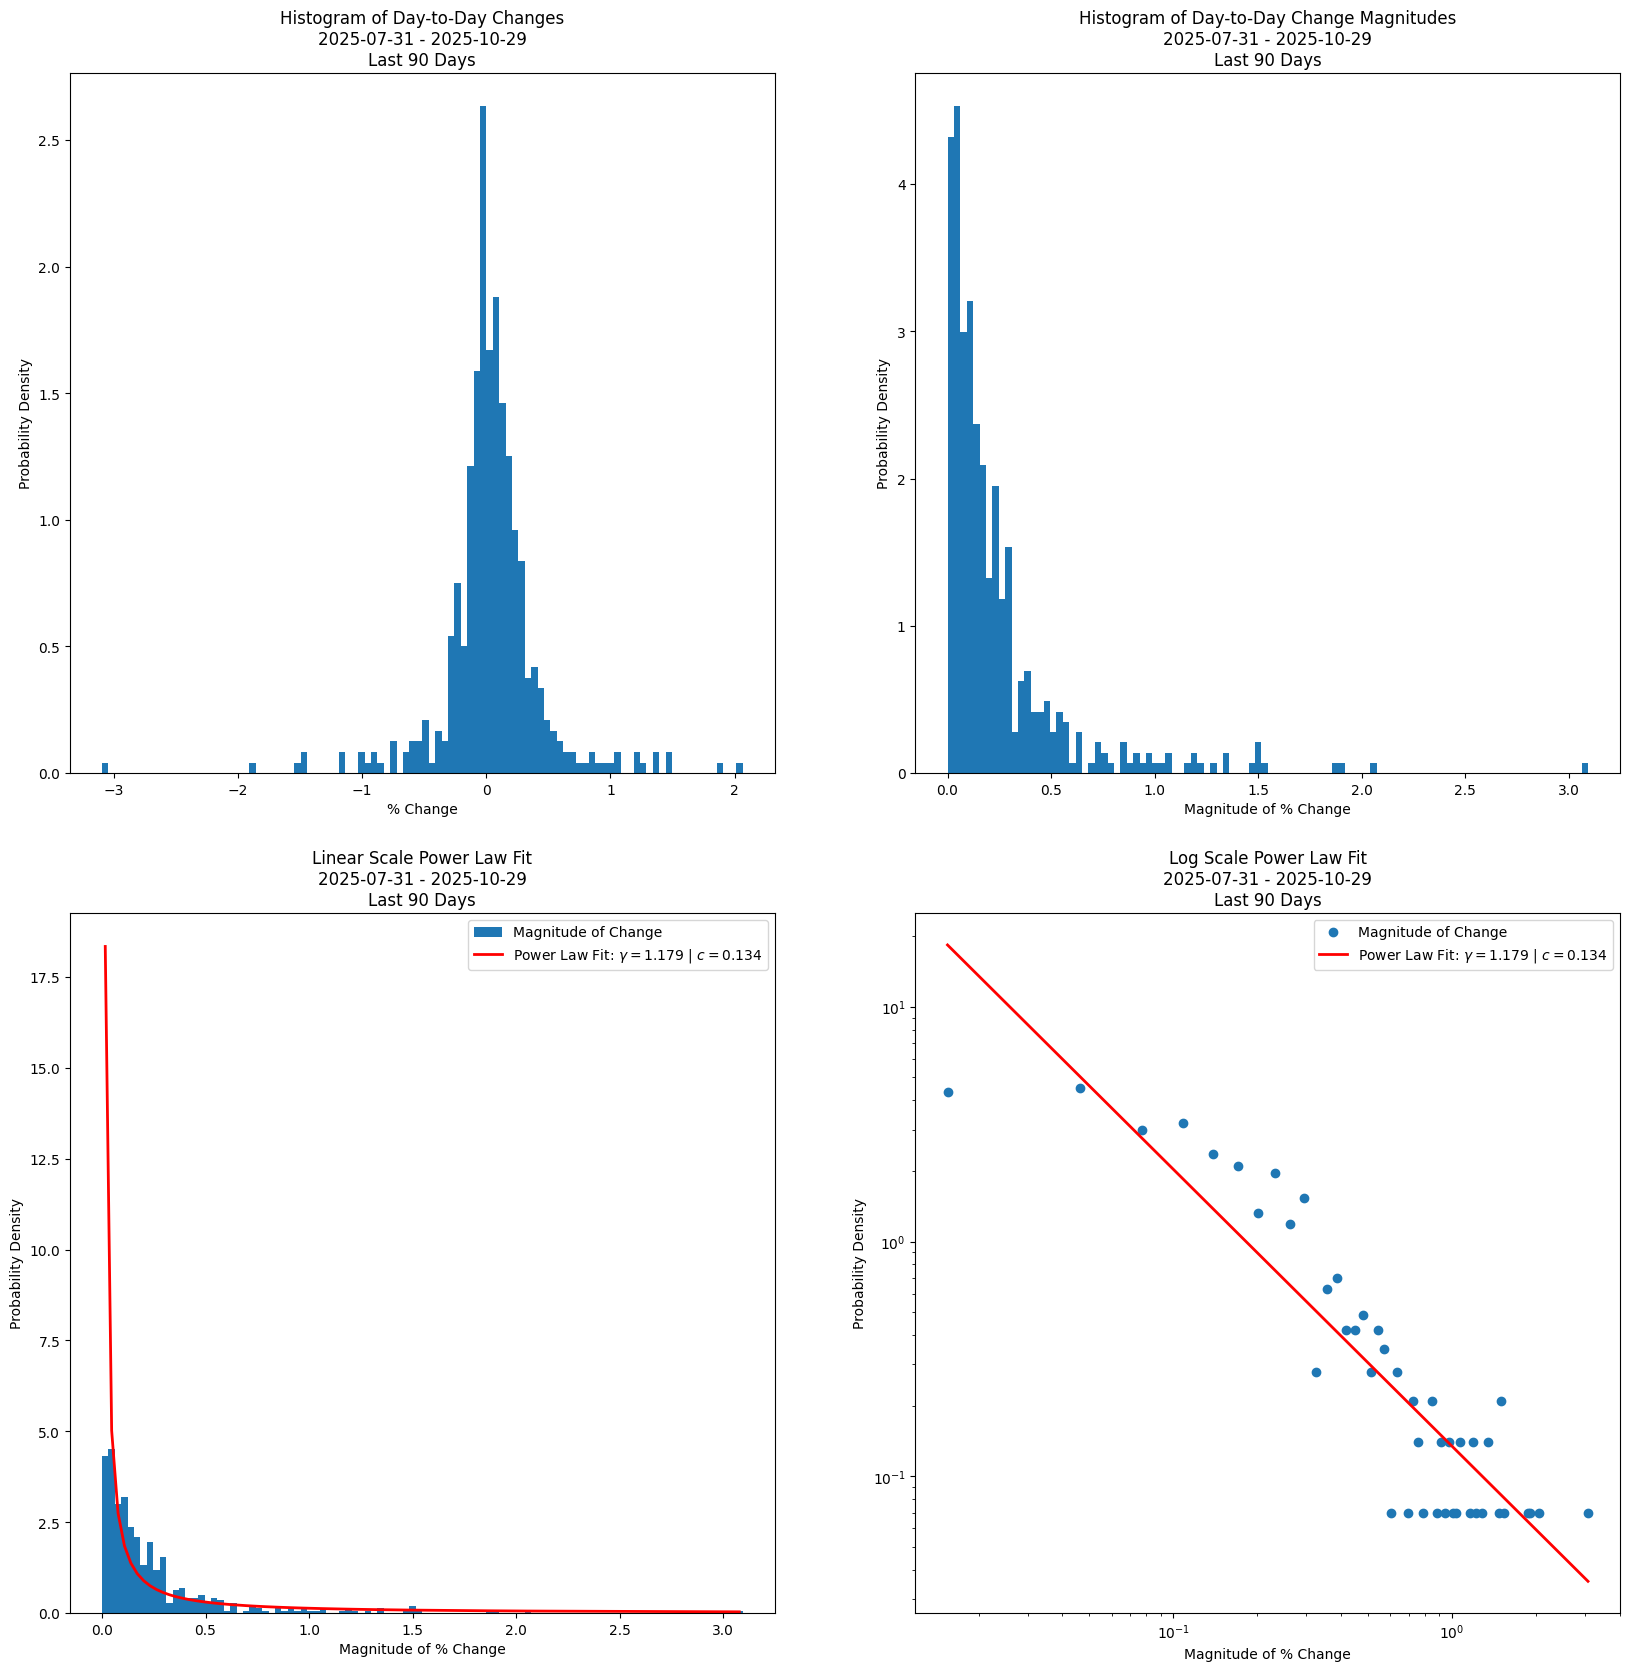

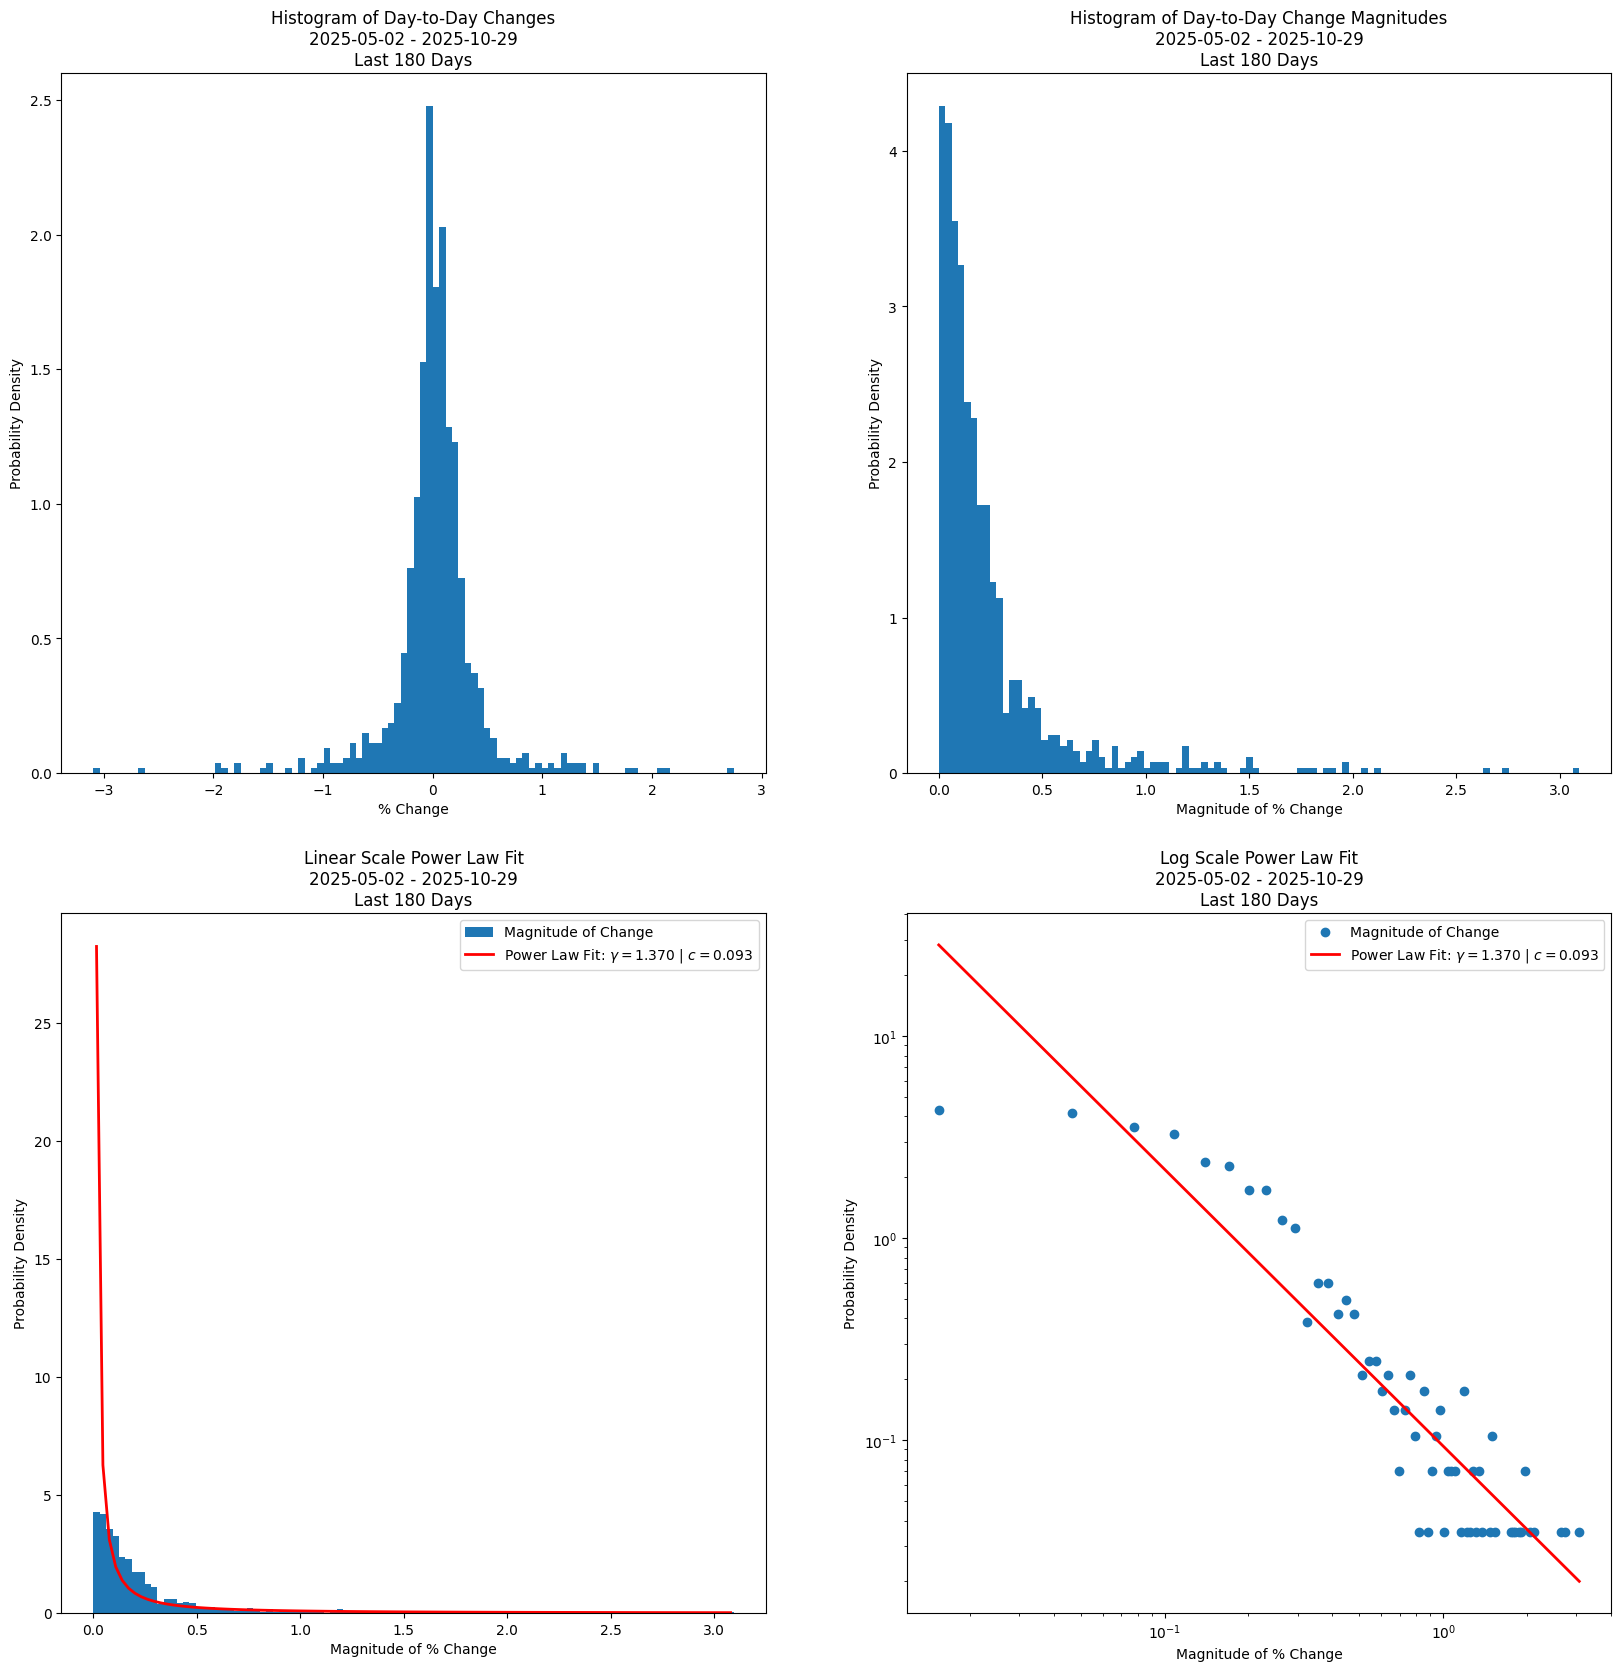

In [ ]:
get_historical_magnitude_plots(symbol = 'GLD',
                                timeframe = '1H',
                                historical_start_date = '2024-01-01',
                                historical_end_date = 'now',
                                day_offsets = [10, 30, 60, 90, 180])

# Backtest - Options

100%|██████████| 83/83 [01:42<00:00,  1.24s/it]


Total Trades: 11
Total P&L: $-5216.00
Win Rate: 9.09%
Average P&L: $-474.18
--- Reconciliation ---
Final Value (+ idle):   $90,217.00
Expected Final Value:   $90,217.00
Difference:             $0.00


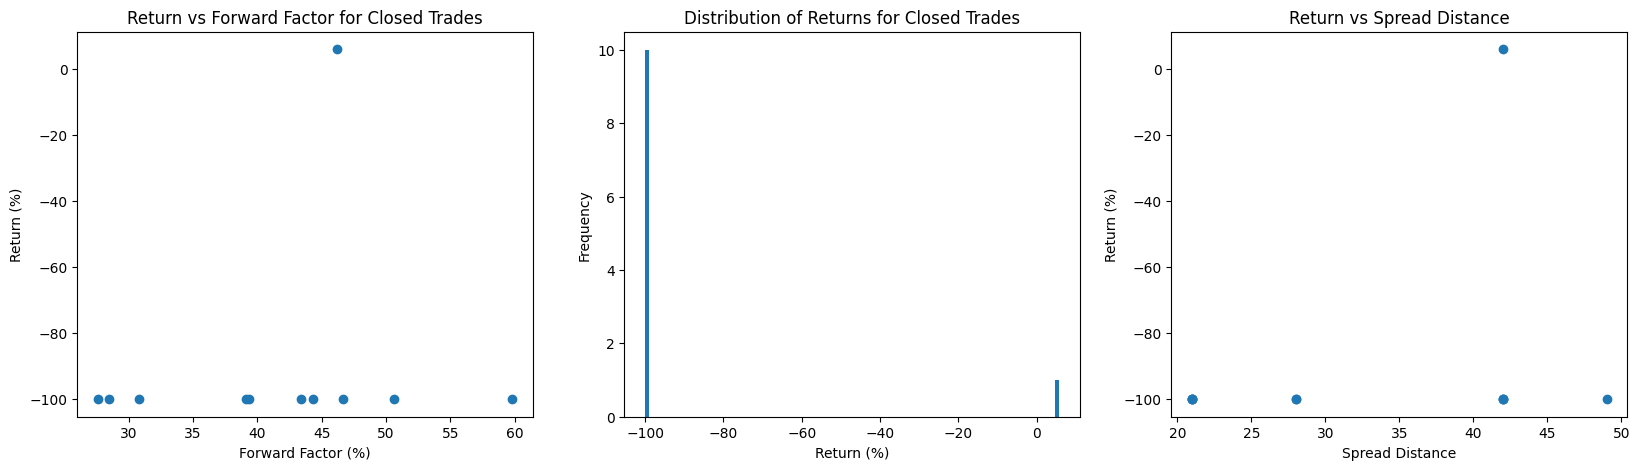

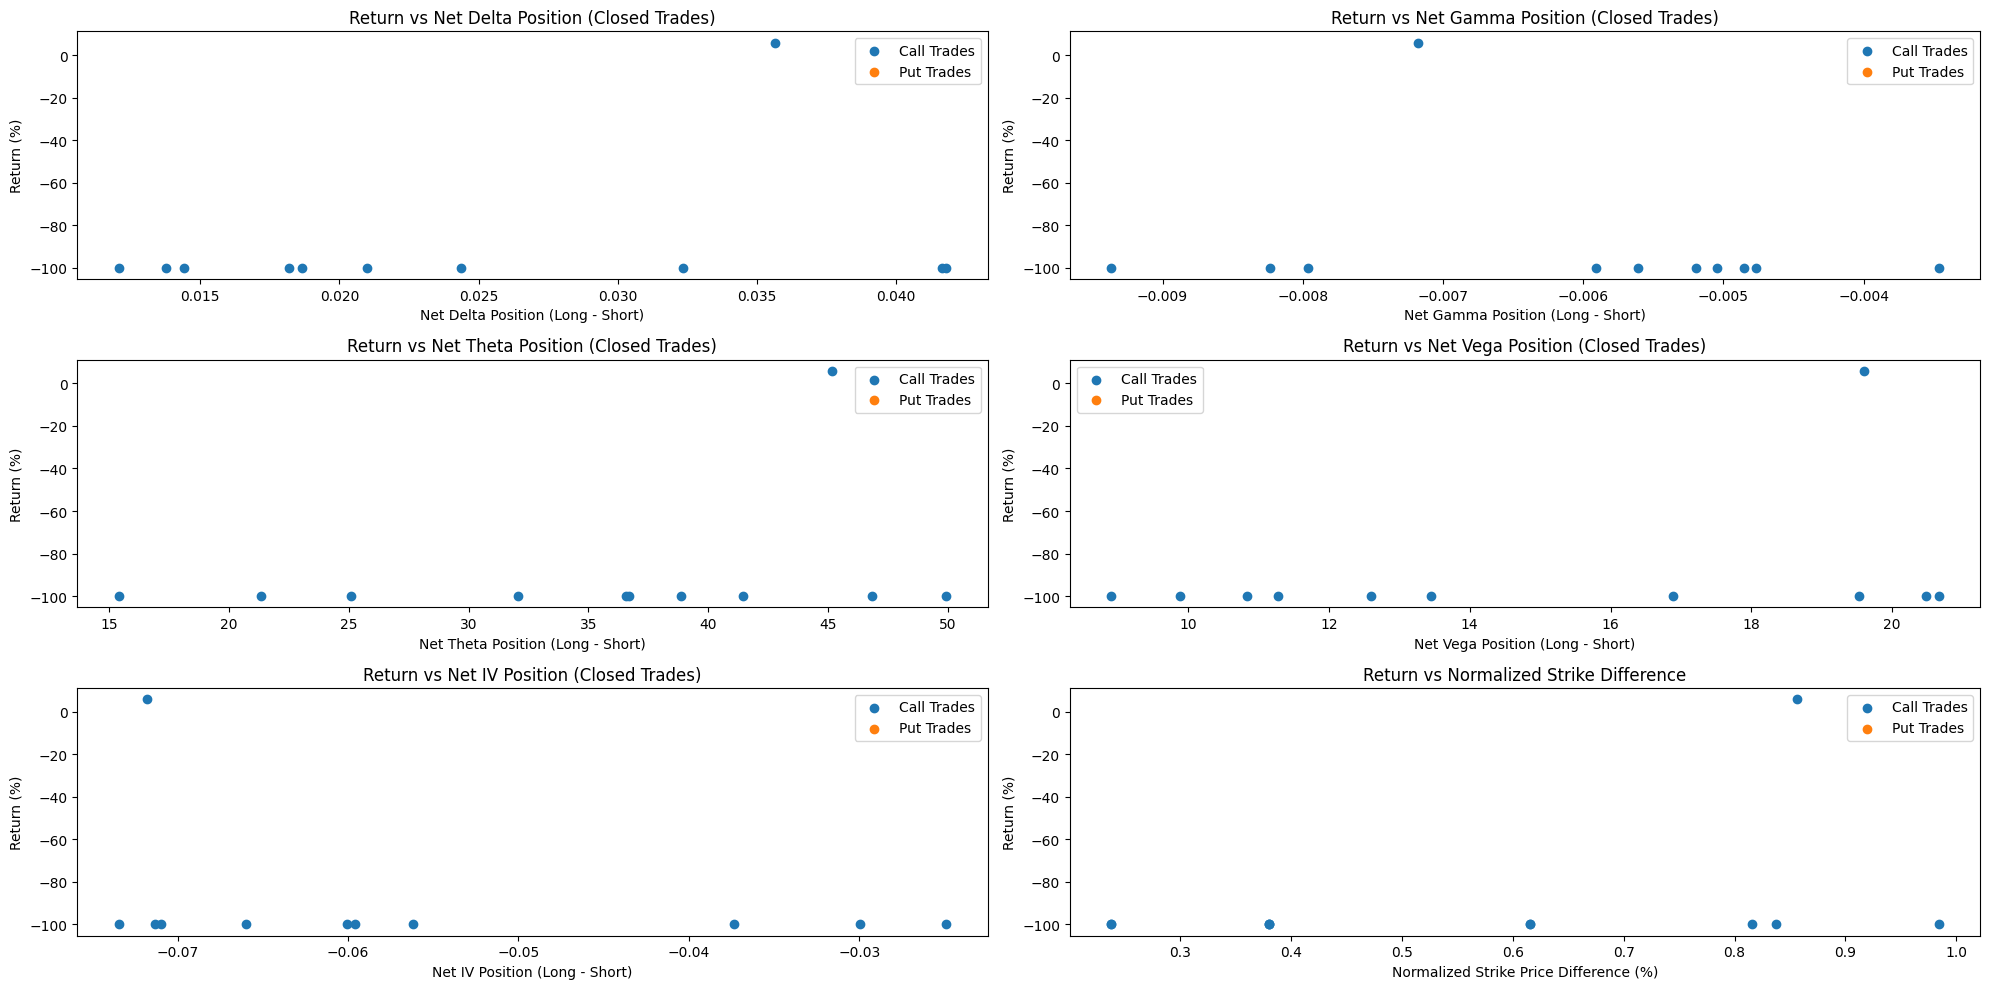

In [4]:
symbol = 'AAPL'
timeframe = '1D'
historical_start_date = '2025-08-01'
historical_end_date = 'now'
initial_capital = 100000  # Starting with $100,000
max_position_ratio_of_capital = 0.1  # Max 10% of cash per trade
max_number_of_open_positions = 200  # Maximum number of open positions



######################
##### Stock Data #####
######################

# Get historical stock price data 
c, h, l, t = get_historical_stock_price(symbol = symbol,
                                            timeframe = timeframe,
                                            historical_start_date = historical_start_date,
                                            historical_end_date = historical_end_date, 
                                            headers = headers)

stock_data = pd.DataFrame([c, h, l, t]).T
stock_data.columns = ['Mid', 'High', 'Low', 'Date']
stock_data['Date'] = pd.to_datetime(stock_data['Date'])

################################
##### Options Book Keeping #####
################################

# For each day's price, look at available options 
options_price_tracker = {}

# Keep track of symbols seen so far to make data pull easier
options_seen = set()

# In-memory cache: avoid repeatedly loading pickle if data is already present/fresh
options_cache_memory = {}  # dict[contract_symbol] -> DataFrame


# Keep track of open positions and their P&L
open_positions = {}  # {trade_id: {'entry_date', 'expiry_date', 'short_leg', 'long_leg', 'entry_credit', 'current_value'}}
closed_positions = []  # List of completed trades with P&L
trade_id_counter = 0

# Portfolio value tracking over time
portfolio_history = []
current_cash = initial_capital * max_position_ratio_of_capital
total_capital_deployed = 0
positions_history = []

conf_list = []

#################################
##### Iterate Over Each Day #####
#################################

for high, low, mid, current_date in tqdm(list(zip(h, l, c, t))):
    
    #######################################
    ##### Get Historical Options Data #####
    #######################################

    # Filter options by strike price +/- 5% from current stock price 
    max_strike = high + (0.05 * high)
    min_strike = low - (0.05 * low)
    
    
    # Generate options symbols from strike price and expiry date
    put_option_symbols = generate_option_symbols(symbol = symbol,
                                                 current_date = current_date,
                                                 end_date_delta = (25, 120),
                                                 min_strike = min_strike,
                                                 max_strike = low,
                                                 strike_increment = 1, 
                                                 op_type = 'put')
    
    call_option_symbols = generate_option_symbols(symbol = symbol,
                                             current_date = current_date,
                                             end_date_delta = (25, 120),
                                             min_strike = high,
                                             max_strike = max_strike,
                                             strike_increment = 1, 
                                             op_type = 'call')
    
    
    # Get unseen options symbols since the previous iteration would have already pulled data 
    put_option_symbols = [s for s in put_option_symbols if s not in options_seen]
    call_option_symbols = [s for s in call_option_symbols if s not in options_seen]

    
    
    # Get historical data for options symbols generated (in-memory cache aware)
    put_options_price_tracker = get_historical_options_data_cached_fast(option_symbols = put_option_symbols,
                                                        current_date = current_date,
                                                        stock_data  = stock_data,
                                                        timeframe = '1D', 
                                                        headers = headers)
    
    call_options_price_tracker = get_historical_options_data_cached_fast(option_symbols = call_option_symbols,
                                                        current_date = current_date,
                                                        stock_data  = stock_data,
                                                        timeframe = '1D', 
                                                        headers = headers)
    
    # Keep track of all options symbols seen so far 
    options_seen = options_seen.union(set(put_option_symbols))
    options_seen = options_seen.union(set(call_option_symbols))
    
    # # Merge dataframes for current time step
    # for key in sorted(put_options_price_tracker.keys()):
    #     if key not in options_price_tracker:
    #         options_price_tracker[key] = put_options_price_tracker[key]
    #     else: 
    #         options_price_tracker[key] = pd.concat([options_price_tracker[key], put_options_price_tracker[key]])
        
    for key in sorted(call_options_price_tracker.keys()):
        if key not in options_price_tracker:
            options_price_tracker[key] = call_options_price_tracker[key]
        else: 
            options_price_tracker[key] = pd.concat([options_price_tracker[key], call_options_price_tracker[key]])
    
    concatenated_options = pd.concat(options_price_tracker.values())
    
    # Make sure we only look at out of money options 
    concatenated_options = concatenated_options[

                                ((concatenated_options['Type'] == 'call') &
                                (concatenated_options['Strike Price'] > concatenated_options['Current Stock Price'])) |
        
                                ((concatenated_options['Type'] == 'put') &
                                (concatenated_options['Strike Price'] < concatenated_options['Current Stock Price']))
                            ]
    
    current_options = concatenated_options[concatenated_options['Current Date'].dt.date == pd.to_datetime(current_date).date()]

    
    #######################################
    ##### Options Strategy Definition #####
    #######################################
    
    # Calendar Spread - Ensure Same Strike Price 
    strike_group = {int(key): group for key, group in current_options.groupby('Strike Price', sort = True)}

    # Identify Options Pairs Based on Forward Factor 
    list_of_options_dataframes = filter_option_trades_by_ff(strike_group = strike_group,
                                                            current_price = mid,
                                                            min_time_distance = 20,
                                                            max_time_distance = 120,
                                                            min_ff_perc = 20, 
                                                            max_ff_perc = 60,
                                                            current_date = current_date, 
                                                            print_output = False)
    
    # Sort by returned forward factors
    list_of_options_dataframes = sorted(list_of_options_dataframes, key = lambda x: x['Forward Factor'][0], reverse = True)
    
    #### Sort by model confidence ##########
    list_of_options = []
    for idx, options_df in enumerate(list_of_options_dataframes):
        conf, reg_pred = get_model_confidence(underlying_price = mid,
                                            options_df = options_df, 
                                            model_name='alpaca_multi_model_calendar_spread_v6.pth',
                                            params_name='alpaca_multi_model_calendar_spread_params_v6.pkl', 
                                            model_dims = 512)
        if conf[0] >= 0.6 and conf[0] <= 0.9 and reg_pred[0] > 1.5:
            list_of_options.append((conf, reg_pred, options_df))

    sorted_options = sorted(list_of_options, key=lambda x: x[0][0], reverse=True)
    list_of_options_dataframes = []
    for conf, reg_pred, options_df in sorted_options:
        list_of_options_dataframes.append(options_df)
        conf_list.append([conf[0], reg_pred[0], options_df])
    #############################################

    # Calculate current portfolio value before opening new trades
    open_positions_value = get_all_open_positions_value(open_positions)
    current_portfolio_value = current_cash + open_positions_value
    
    ##############################################
    ##### Keep Track and Update Prior Trades #####
    ##############################################
    portfolio_history, open_positions, closed_positions, current_cash = check_existing_positions(portfolio_history,
                                                                            open_positions,
                                                                            closed_positions,
                                                                            current_date,
                                                                            current_cash,
                                                                            options_price_tracker,
                                                                            short_exit_limits = (-200, 200),
                                                                            long_exit_limits = (-200, 200),
                                                                            position_exit_limits = (-200, 200), 
                                                                            stock_data = stock_data)
    
    
    ##############################
    ##### Execute New Trades #####
    ##############################
    open_positions, num_trades_executed_today, current_cash, trade_id_counter = execute_identified_trades(list_of_options_dataframes = list_of_options_dataframes,
                                                                                        open_positions = open_positions,
                                                                                        current_date = current_date,
                                                                                        current_cash = current_cash,
                                                                                        trade_id_counter = trade_id_counter,
                                                                                        total_capital_deployed = total_capital_deployed,
                                                                                        max_number_of_open_positions = max_number_of_open_positions,
                                                                                        stock_strike_deviation_limit = 5,
                                                                                        max_position_ratio_of_capital_per_trade = 0.01, 
                                                                                        num_contracts_limit = 1)    
    
    
        
        
# After loop completes, create summary DataFrame
closed_trades_df = pd.DataFrame(closed_positions)
portfolio_df = pd.DataFrame(portfolio_history)

if len(closed_trades_df) > 0:
    closed_trades_df['return_pct'] = (closed_trades_df['final_pnl'] / 
                                       closed_trades_df['capital_deployed']) * 100
    
    print(f"Total Trades: {len(closed_trades_df)}")
    print(f"Total P&L: ${closed_trades_df['final_pnl'].sum():.2f}")
    print(f"Win Rate: {(closed_trades_df['final_pnl'] > 0).sum() / len(closed_trades_df) * 100:.2f}%")
    print(f"Average P&L: ${closed_trades_df['final_pnl'].mean():.2f}")

    # Reconciliation check: portfolio value vs closed P&L and open unrealized
    try:
        starting_trading_cash = initial_capital * max_position_ratio_of_capital
        idle_cash = initial_capital - starting_trading_cash

        final_value_with_idle = portfolio_df['total_value'].iloc[-1] + idle_cash
        initial_value_with_idle = portfolio_df['total_value'].iloc[0] + idle_cash

        realized_pnl = closed_trades_df['final_pnl'].sum() if len(closed_trades_df) else 0.0
        open_unrealized_pnl = portfolio_df['open_positions_value'].iloc[-1]

        expected_final_value = initial_capital + realized_pnl + open_unrealized_pnl

        print('--- Reconciliation ---')
        print(f"Final Value (+ idle):   ${final_value_with_idle:,.2f}")
        print(f"Expected Final Value:   ${expected_final_value:,.2f}")
        print(f"Difference:             ${final_value_with_idle - expected_final_value:,.2f}")
    except Exception as e:
        print('Reconciliation check skipped:', e)


# Plot factors vs returns
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

axs[0].scatter(closed_trades_df['forward_factor'], closed_trades_df['return_pct'])
axs[0].set_xlabel('Forward Factor (%)')
axs[0].set_ylabel('Return (%)')
axs[0].set_title('Return vs Forward Factor for Closed Trades')

axs[1].hist(closed_trades_df['return_pct'], bins=100)
axs[1].set_xlabel('Return (%)')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Distribution of Returns for Closed Trades')

axs[2].scatter(closed_trades_df['spread_distance'], closed_trades_df['return_pct'])
axs[2].set_xlabel('Spread Distance')
axs[2].set_ylabel('Return (%)')
axs[2].set_title('Return vs Spread Distance')
plt.show()

call_df = closed_trades_df[closed_trades_df['option_type'] == 'call']
put_df = closed_trades_df[closed_trades_df['option_type'] == 'put']

fig, axes = plt.subplots(3, 2, figsize=(20, 10))

# 1) Net Delta vs Return
axes[0][0].scatter(call_df['Delta_Long'] - call_df['Delta_Short'],
                 call_df['return_pct'], label='Call Trades')
axes[0][0].scatter(put_df['Delta_Long'] - put_df['Delta_Short'],
                 put_df['return_pct'], label='Put Trades')
axes[0][0].set_xlabel('Net Delta Position (Long - Short)')
axes[0][0].set_ylabel('Return (%)')
axes[0][0].set_title('Return vs Net Delta Position (Closed Trades)')
axes[0][0].legend()

# 2) Net Gamma vs Return
axes[0][1].scatter(call_df['Gamma Long'] - call_df['Gamma Short'],
                 call_df['return_pct'], label='Call Trades')
axes[0][1].scatter(put_df['Gamma Long'] - put_df['Gamma Short'],
                 put_df['return_pct'], label='Put Trades')
axes[0][1].set_xlabel('Net Gamma Position (Long - Short)')
axes[0][1].set_ylabel('Return (%)')
axes[0][1].set_title('Return vs Net Gamma Position (Closed Trades)')
axes[0][1].legend()

# 3) Net Theta vs Return
axes[1][0].scatter(call_df['Theta Long'] - call_df['Theta Short'],
                 call_df['return_pct'], label='Call Trades')
axes[1][0].scatter(put_df['Theta Long'] - put_df['Theta Short'],
                 put_df['return_pct'], label='Put Trades')
axes[1][0].set_xlabel('Net Theta Position (Long - Short)')
axes[1][0].set_ylabel('Return (%)')
axes[1][0].set_title('Return vs Net Theta Position (Closed Trades)')
axes[1][0].legend()

# 4) Net Vega vs Return
axes[1][1].scatter(call_df['Vega Long'] - call_df['Vega Short'],
                 call_df['return_pct'], label='Call Trades')
axes[1][1].scatter(put_df['Vega Long'] - put_df['Vega Short'],
                 put_df['return_pct'], label='Put Trades')
axes[1][1].set_xlabel('Net Vega Position (Long - Short)')
axes[1][1].set_ylabel('Return (%)')
axes[1][1].set_title('Return vs Net Vega Position (Closed Trades)')
axes[1][1].legend()

# 5) Net IV vs Return
axes[2][0].scatter(call_df['IV Long'] - call_df['IV Short'],
                 call_df['return_pct'], label='Call Trades')
axes[2][0].scatter(put_df['IV Long'] - put_df['IV Short'],
                 put_df['return_pct'], label='Put Trades')
axes[2][0].set_xlabel('Net IV Position (Long - Short)')
axes[2][0].set_ylabel('Return (%)')
axes[2][0].set_title('Return vs Net IV Position (Closed Trades)')
axes[2][0].legend()

# 6) Normalized Strike Difference vs Return (in %)
x_call = 100 * np.abs(call_df['entry_stock_price'] - call_df['strike']) / call_df['strike']
x_put = 100 * np.abs(put_df['entry_stock_price'] - put_df['strike']) / put_df['strike']
axes[2][1].scatter(x_call, call_df['return_pct'], label='Call Trades')
axes[2][1].scatter(x_put, put_df['return_pct'], label='Put Trades')
axes[2][1].set_xlabel('Normalized Strike Price Difference (%)')
axes[2][1].set_ylabel('Return (%)')
axes[2][1].set_title('Return vs Normalized Strike Difference')
axes[2][1].legend()
plt.tight_layout()
plt.show()


In [5]:
[[x[0], x[1]] for x in conf_list]

[[0.87357885, 1.5430709],
 [0.8976986, 2.7301493],
 [0.8822387, 3.120265],
 [0.8809146, 3.0158668],
 [0.8748488, 1.567866],
 [0.87519246, 2.2994316],
 [0.8791212, 1.7895662],
 [0.77999395, 2.417199],
 [0.864359, 1.5949959],
 [0.8926783, 2.3604949],
 [0.7966382, 1.5524682],
 [0.87951624, 1.781712],
 [0.8726546, 1.625433],
 [0.8367025, 1.612056],
 [0.887566, 1.7971741],
 [0.8334358, 1.7443469]]

BACKTEST PERFORMANCE SUMMARY (Full Capital)
Initial Capital:        $100,000.00
Final Portfolio Value:  $111,662.00
Total Return:           11.66%
Annualized Return:      34.48%
Sharpe Ratio:           0.70
Maximum Drawdown:       -16.02%

Trading Period:         2025-07-01 to 2025-11-14
Days Elapsed:           136

Total Trades:           10
Win Rate:               70.00%
Average Win:            $4974.14
Average Loss:           $-1596.67
Profit Factor:          7.27


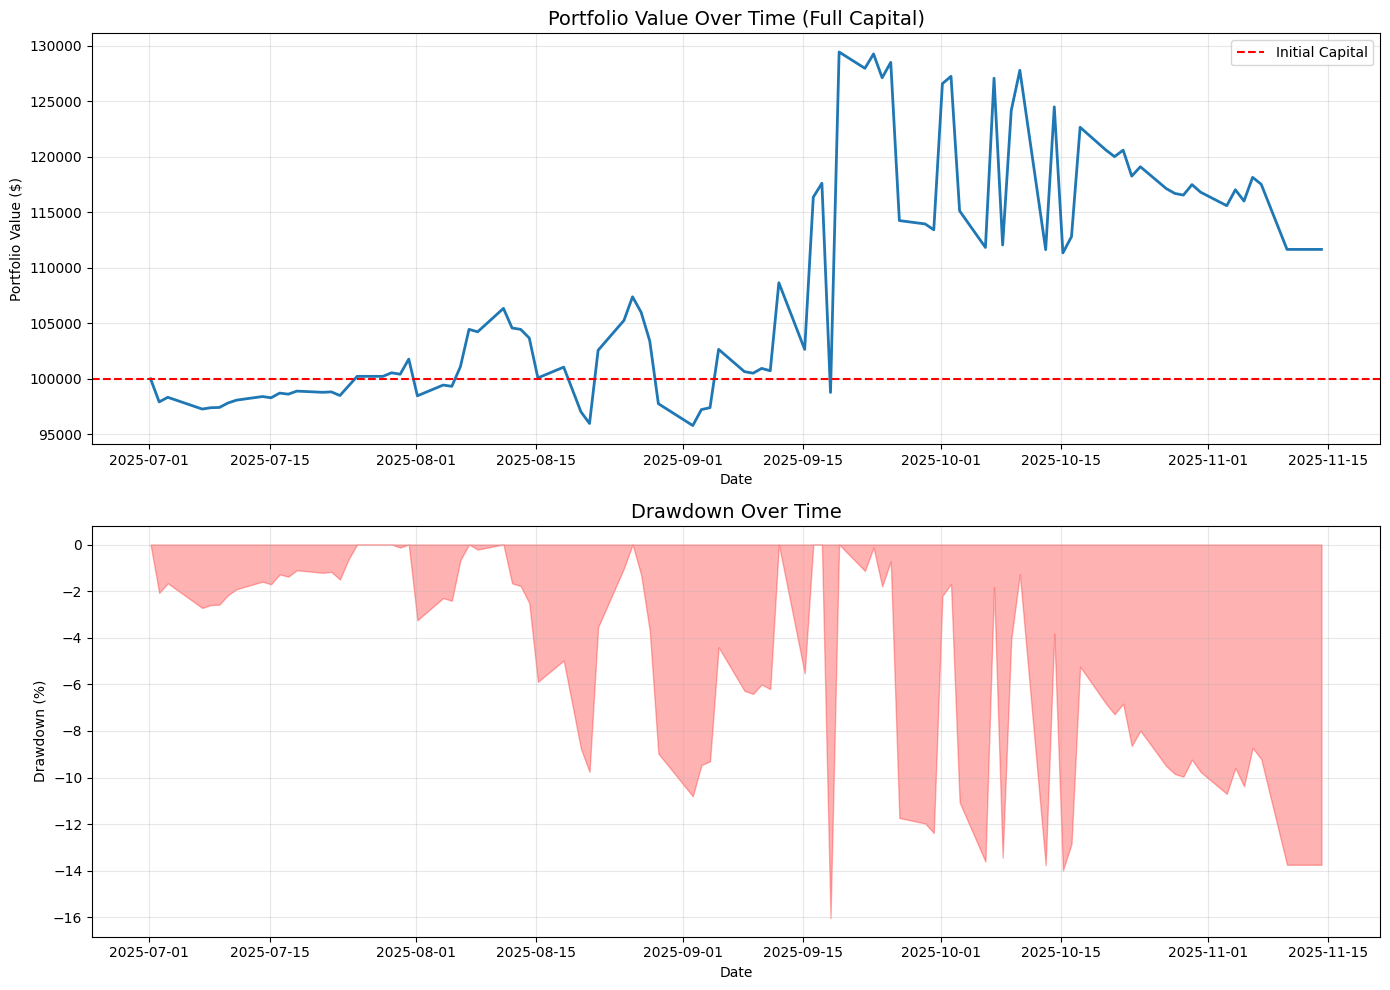

In [ ]:
# Convert to DataFrame for analysis
portfolio_df = pd.DataFrame(portfolio_history)
closed_trades_df = pd.DataFrame(closed_positions)

# Baseline: only a fraction of capital was actively traded; add idle cash back to equity
starting_trading_cash = initial_capital * max_position_ratio_of_capital  # cash allocated to trades
idle_cash = initial_capital - starting_trading_cash                      # idle cash held constant

# Build a full-equity series including idle cash
portfolio_df['equity_full'] = portfolio_df['total_value'] + idle_cash

# Calculate performance metrics on full equity
final_portfolio_value = portfolio_df['equity_full'].iloc[-1]
total_return = ((final_portfolio_value - initial_capital) / initial_capital) * 100

# Calculate time period
start_date = pd.to_datetime(historical_start_date, utc=True)
end_date = pd.to_datetime(portfolio_df['date'].iloc[-1], utc=True)
days_elapsed = (end_date - start_date).days
years_elapsed = days_elapsed / 365.25 if days_elapsed > 0 else np.nan

# Annualized return (guard for very short periods)
if years_elapsed and not np.isnan(years_elapsed) and years_elapsed > 0:
    annualized_return = ((final_portfolio_value / initial_capital) ** (1 / years_elapsed) - 1) * 100
else:
    annualized_return = np.nan

# Calculate daily returns on full equity
portfolio_df['daily_return'] = portfolio_df['equity_full'].pct_change()

# Sharpe Ratio (assuming risk-free rate of 4%)
risk_free_rate = 0.04
risk_free_daily = risk_free_rate / 252
excess_returns = portfolio_df['daily_return'] - risk_free_daily
excess_std = excess_returns.std()
sharpe_ratio = (excess_returns.mean() / excess_std) * np.sqrt(252) if excess_std and not np.isnan(excess_std) else np.nan

# Maximum drawdown on full equity
portfolio_df['cumulative_max'] = portfolio_df['equity_full'].cummax()
portfolio_df['drawdown'] = (portfolio_df['equity_full'] - portfolio_df['cumulative_max']) / portfolio_df['cumulative_max']
max_drawdown = portfolio_df['drawdown'].min() * 100

# Win rate and profit factor
if len(closed_trades_df) > 0:
    win_rate = (closed_trades_df['final_pnl'] > 0).sum() / len(closed_trades_df) * 100
    avg_win = closed_trades_df[closed_trades_df['final_pnl'] > 0]['final_pnl'].mean()
    avg_loss = closed_trades_df[closed_trades_df['final_pnl'] < 0]['final_pnl'].mean()
    total_wins = closed_trades_df[closed_trades_df['final_pnl'] > 0]['final_pnl'].sum()
    total_losses = closed_trades_df[closed_trades_df['final_pnl'] < 0]['final_pnl'].sum()
    profit_factor = (total_wins / abs(total_losses)) if total_losses != 0 else np.inf
else:
    win_rate = avg_win = avg_loss = 0
    profit_factor = np.nan

# Print Performance Summary
print("=" * 60)
print("BACKTEST PERFORMANCE SUMMARY (Full Capital)")
print("=" * 60)
print(f"Initial Capital:        ${initial_capital:,.2f}")
print(f"Final Portfolio Value:  ${final_portfolio_value:,.2f}")
print(f"Total Return:           {total_return:.2f}%")
print(f"Annualized Return:      {annualized_return:.2f}%" if not np.isnan(annualized_return) else "Annualized Return:      n/a")
print(f"Sharpe Ratio:           {sharpe_ratio:.2f}" if not np.isnan(sharpe_ratio) else "Sharpe Ratio:           n/a")
print(f"Maximum Drawdown:       {max_drawdown:.2f}%")
print(f"\nTrading Period:         {start_date.date()} to {end_date.date()}")
print(f"Days Elapsed:           {days_elapsed}")
print(f"\nTotal Trades:           {len(closed_trades_df)}")
print(f"Win Rate:               {win_rate:.2f}%")
print(f"Average Win:            ${0 if np.isnan(avg_win) else avg_win:.2f}")
print(f"Average Loss:           ${0 if np.isnan(avg_loss) else avg_loss:.2f}")
print(f"Profit Factor:          {profit_factor:.2f}" if not np.isnan(profit_factor) and not np.isinf(profit_factor) else f"Profit Factor:          {profit_factor}")
print("=" * 60)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Portfolio value (full equity)
axes[0].plot(portfolio_df['date'], portfolio_df['equity_full'], linewidth=2)
axes[0].axhline(y=initial_capital, color='r', linestyle='--', label='Initial Capital')
axes[0].set_title('Portfolio Value Over Time (Full Capital)', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
axes[1].fill_between(portfolio_df['date'], portfolio_df['drawdown'] * 100, 0, alpha=0.3, color='red')
axes[1].set_title('Drawdown Over Time', fontsize=14)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Alternate Backtest

In [ ]:
symbol_list = ['AAPL', 'MSFT', 'QCOM', 'GOOGL', 'AMZN', 'TSLA', 'PINS', 'NFLX', 'NVDA', 'META', 'SPY', 'QQQ'] + ['RIVN', 'CRWV', 'SMR', 'CEG', 'CAT'] + ['GLD']
for symbol in tqdm(symbol_list):

    # symbol = 'MSFT'
    timeframe = '1D'
    historical_start_date = '2024-01-01'
    historical_end_date = 'now'
    list_of_options_dataframes = {}

    # Keep track of symbols seen so far to make data pull easier
    options_seen = set()

    # For each day's price, look at available options 
    options_price_tracker = {}


    ######################
    ##### Stock Data #####
    ######################

    # Get historical stock price data 
    c, h, l, t = get_historical_stock_price(symbol = symbol,
                                                timeframe = timeframe,
                                                historical_start_date = historical_start_date,
                                                historical_end_date = historical_end_date, 
                                                headers = headers)

    stock_data = pd.DataFrame([c, h, l, t]).T
    stock_data.columns = ['Mid', 'High', 'Low', 'Date']
    stock_data['Date'] = pd.to_datetime(stock_data['Date'])

    ################################
    ##### Options Book Keeping #####
    ################################


    for high, low, mid, current_date in tqdm(list(zip(h, l, c, t))):
        
        #######################################
        ##### Get Historical Options Data #####
        #######################################

        # Filter options by strike price +/- 10% from current stock price 
        max_strike = high + (0.1 * high)
        min_strike = low - (0.1 * low)
        
        
        # Generate options symbols from strike price and expiry date
        put_option_symbols = generate_option_symbols(symbol = symbol,
                                                    current_date = current_date,
                                                    end_date_delta = (25, 120),
                                                    min_strike = min_strike,
                                                    max_strike = low,
                                                    strike_increment = 1, 
                                                    op_type = 'put')
        
        call_option_symbols = generate_option_symbols(symbol = symbol,
                                                current_date = current_date,
                                                end_date_delta = (25, 120),
                                                min_strike = high,
                                                max_strike = max_strike,
                                                strike_increment = 1, 
                                                op_type = 'call')
        
        
        # Get unseen options symbols since the previous iteration would have already pulled data 
        put_option_symbols = [s for s in put_option_symbols if s not in options_seen]
        call_option_symbols = [s for s in call_option_symbols if s not in options_seen]

        
        
        # Get historical data for options symbols generated (in-memory cache aware)
        put_options_price_tracker = get_historical_options_data_cached_fast(option_symbols = put_option_symbols,
                                                            current_date = current_date,
                                                            stock_data  = stock_data,
                                                            timeframe = '1D', 
                                                            headers = headers)
        
        call_options_price_tracker = get_historical_options_data_cached_fast(option_symbols = call_option_symbols,
                                                            current_date = current_date,
                                                            stock_data  = stock_data,
                                                            timeframe = '1D', 
                                                            headers = headers)
        
        # Keep track of all options symbols seen so far 
        options_seen = options_seen.union(set(put_option_symbols))
        options_seen = options_seen.union(set(call_option_symbols))
        
        # Merge dataframes for current time step
        for key in sorted(put_options_price_tracker.keys()):
            if key not in options_price_tracker:
                options_price_tracker[key] = put_options_price_tracker[key]
            else: 
                options_price_tracker[key] = pd.concat([options_price_tracker[key], put_options_price_tracker[key]])
            
        for key in sorted(call_options_price_tracker.keys()):
            if key not in options_price_tracker:
                options_price_tracker[key] = call_options_price_tracker[key]
            else: 
                options_price_tracker[key] = pd.concat([options_price_tracker[key], call_options_price_tracker[key]])
        
        concatenated_options = pd.concat(options_price_tracker.values())
        
        # Make sure we only look at out of money options 
        concatenated_options = concatenated_options[

                                    ((concatenated_options['Type'] == 'call') &
                                    (concatenated_options['Strike Price'] > concatenated_options['Current Stock Price'])) |
            
                                    ((concatenated_options['Type'] == 'put') &
                                    (concatenated_options['Strike Price'] < concatenated_options['Current Stock Price']))
                                ]
        
        current_options = concatenated_options[concatenated_options['Current Date'].dt.date == pd.to_datetime(current_date).date()]

        
        #######################################
        ##### Options Strategy Definition #####
        #######################################
        
        # Calendar Spread - Ensure Same Strike Price 
        strike_group = {int(key): group for key, group in current_options.groupby('Strike Price', sort = True)}

        # Identify Options Pairs Based on Forward Factor 
        options_dataframes = filter_option_trades_by_ff(strike_group = strike_group,
                                                                current_price = mid,
                                                                min_time_distance = 20,
                                                                max_time_distance = 160,
                                                                min_ff_perc = 10, 
                                                                max_ff_perc = 60,
                                                                current_date = current_date, 
                                                                print_output = False)
        
        # Sort by returned forward factors
        options_dataframes = sorted(options_dataframes, key = lambda x: x['Forward Factor'][0], reverse = True)
        list_of_options_dataframes[current_date] = options_dataframes

        with open(os.path.join(cache_path, f'options/list_of_options_dataframes_{symbol}.pkl'), 'wb') as file:
            pkl.dump(list_of_options_dataframes, file)
    

Long Profit: 0.030 | Long Return: 4.615%
Short Profit: 0.000 | Short Return: 0.000%
Max Profit: 0.030 | Max Return: 4.615%
Min Profit: 0.000 | Min Return: 0.000%


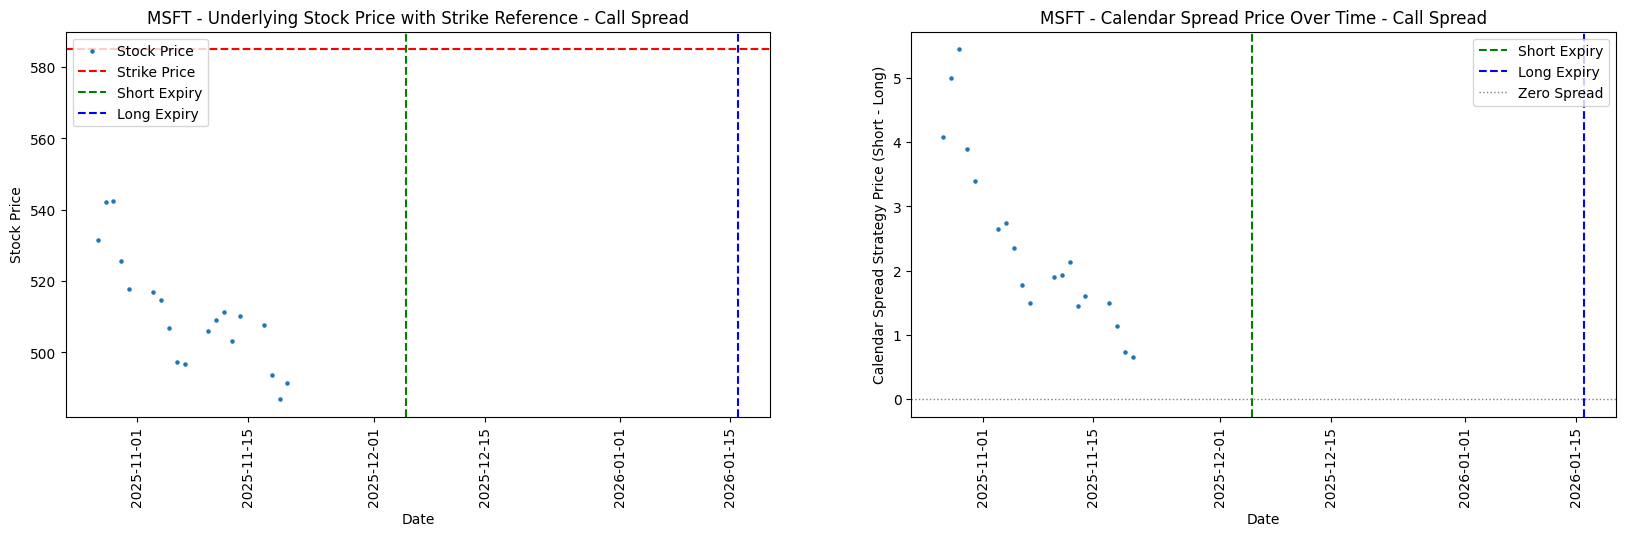

In [ ]:
options_idx = 0
short = list_of_options_dataframes[current_date][options_idx]['Symbol'].values[0]
long = list_of_options_dataframes[current_date][options_idx]['Symbol'].values[1]

df1 = options_df[short].copy()
df2 = options_df[long].copy()

# Compute expiration dates once
short_expiry = pd.to_datetime(df1['Expiration Date'].iloc[0]).date()
long_expiry = pd.to_datetime(df2['Expiration Date'].iloc[0]).date()

intersection = set(df1['Current Date'].dt.date).intersection(set(df2['Current Date'].dt.date))
long_difference = set(df2['Current Date'].dt.date) - intersection

entry_price = - (df1[df1['Current Date'].dt.date == current_date.date()]['Current Option Price'].values[0] - df2[df2['Current Date'].dt.date == current_date.date()]['Current Option Price'].values[0])
short_expiry_price = -(df1.iloc[-1]['Current Option Price'] - df2[df2['Current Date'].dt.date == df1.iloc[-1]['Current Date'].date()]['Current Option Price']).values[0]
long_expiry_price = df2.iloc[-1]['Current Option Price']

long_profit = long_expiry_price - entry_price
short_profit = short_expiry_price - entry_price
max_profit = max(long_profit, short_profit)
min_profit = min(long_profit, short_profit)
print (f'Long Profit: {long_profit:.3f} | Long Return: {long_profit / abs(entry_price) * 100:.3f}%')
print (f'Short Profit: {short_profit:.3f} | Short Return: {short_profit / abs(entry_price) * 100:.3f}%')
print (f'Max Profit: {max_profit:.3f} | Max Return: {max_profit / abs(entry_price) * 100:.3f}%')
print (f'Min Profit: {min_profit:.3f} | Min Return: {min_profit / abs(entry_price) * 100:.3f}%')

strategy_price = []

for d in intersection:
    short_row = df1[df1['Current Date'].dt.date == d]
    long_row = df2[df2['Current Date'].dt.date == d]

    short_price = short_row['Current Option Price'].values[0]
    long_price = long_row['Current Option Price'].values[0]

    strategy_price.append([-(short_price - long_price), d])

for price, date in df2[df2['Current Date'].dt.date.isin(long_difference)][['Current Option Price', 'Current Date']].values:
    strategy_price.append([price, date.date()])

stock_price = []
for sp, date in df2[df2['Current Date'].dt.date.isin(intersection.union(long_difference))][['Current Stock Price', 'Current Date']].values:
    stock_price.append([sp, date.date()])


fig, axs = plt.subplots(1, 2, figsize=(20, 5))



# Left subplot: underlying stock price with strike and expirations
axs[0].scatter(x=[x[1] for x in stock_price],
               y=[x[0] for x in stock_price],
               label='Stock Price',
               s=5)
# Horizontal line at strike price reference
axs[0].axhline(y=df2['Strike Price'].values[0], color='r', linestyle='--', linewidth=1.5, label='Strike Price')
# Vertical lines for expirations
axs[0].axvline(short_expiry, color='g', linestyle='--', linewidth=1.5, label='Short Expiry')
axs[0].axvline(long_expiry, color='b', linestyle='--', linewidth=1.5, label='Long Expiry')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Stock Price')
axs[0].set_title(f'{symbol} - Underlying Stock Price with Strike Reference - {df1["Type"].values[0].capitalize()} Spread')
axs[0].legend()

# Right subplot: calendar spread strategy price with expirations and zero line
axs[1].scatter(x=[x[1] for x in strategy_price],
               y=[x[0] for x in strategy_price],
               s=5)
# Vertical lines for expirations
axs[1].axvline(short_expiry, color='g', linestyle='--', linewidth=1.5, label='Short Expiry')
axs[1].axvline(long_expiry, color='b', linestyle='--', linewidth=1.5, label='Long Expiry')
# Horizontal reference line at zero spread
axs[1].axhline(y=0, color='gray', linestyle=':', linewidth=1, label='Zero Spread')
axs[1].set_xlabel('Date')
axs[1].set_ylabel('Calendar Spread Strategy Price (Short - Long)')
axs[1].set_title(f'{symbol} - Calendar Spread Price Over Time - {df1["Type"].values[0].capitalize()} Spread')
axs[1].legend()

# Rotate x-axis tick labels to 90 degrees for readability
for ax in axs:
    ax.tick_params(axis='x', labelrotation=90)

plt.show()

In [60]:
nums = [1, 2,1, 3]
counts = {}
for i in nums:
    counts[i] = nums.count(i)
counts = sorted(counts.items(), key = lambda kv: (-kv[1], kv[0]))

In [61]:
counts

[(1, 2), (2, 1), (3, 1)]

# Other: Power Law Distribution Controls  

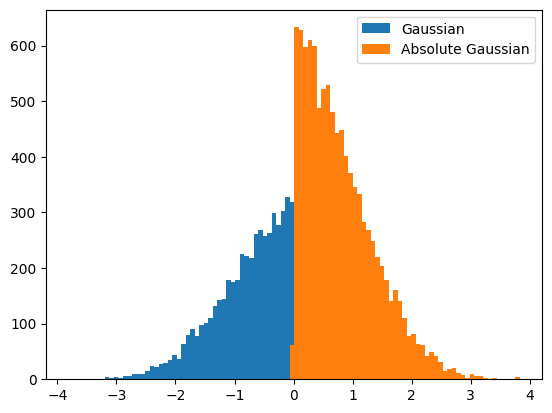

In [ ]:
y = np.random.randn(10000)
abs_y = np.abs(y)
bins = plt.hist(y, bins = 100, label = 'Gaussian')
bins_abs = plt.hist(abs_y, bins = bins[1], label = 'Absolute Gaussian')
plt.legend()
plt.show()

/var/folders/g7/2jc8pp3979bb81nstc9qs3900000gn/T/ipykernel_16810/541336630.py:2: RuntimeWarning: divide by zero encountered in log
  plt.scatter(y = np.exp(power_law(np.log(bins_abs[0][46:]), 1, 0)),
/var/folders/g7/2jc8pp3979bb81nstc9qs3900000gn/T/ipykernel_16810/541336630.py:4: RuntimeWarning: divide by zero encountered in log
  plt.scatter(y = np.exp(power_law(np.log(bins_abs[0][46:]), 2, 0)),
/var/folders/g7/2jc8pp3979bb81nstc9qs3900000gn/T/ipykernel_16810/541336630.py:6: RuntimeWarning: divide by zero encountered in log
  plt.scatter(y = np.exp(power_law(np.log(bins_abs[0][46:]), 3, 0)),
/var/folders/g7/2jc8pp3979bb81nstc9qs3900000gn/T/ipykernel_16810/541336630.py:8: RuntimeWarning: divide by zero encountered in log
  plt.scatter(y = np.exp(power_law(np.log(bins_abs[0][46:]), 5, 0)),
/var/folders/g7/2jc8pp3979bb81nstc9qs3900000gn/T/ipykernel_16810/541336630.py:10: RuntimeWarning: divide by zero encountered in log
  plt.scatter(y = np.exp(power_law(np.log(bins_abs[0][46:]), 10, 0))

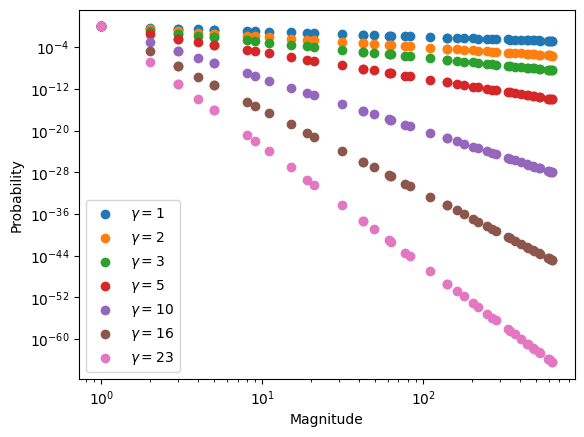

In [ ]:
plt.figure()
for k in [1, 2, 3, 5, 10, 16, 23]:
    plt.scatter(y = np.exp(power_law(np.log(bins_abs[0][46:]), k, 0)),
                x = bins_abs[0][46:], label = f'$\gamma = {k}$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Magnitude')
plt.ylabel('Probability')
plt.legend()
plt.show()

In [ ]:
with open(os.path.join(cache_path, 'PINS_closed_trades.pkl'), 'rb') as file: 
    d = pkl.load(file)